### Heating Rate Analysis
2026-07-28

Aim is to vastly simplify the current analysis of circa 2024 data.

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
from scipy.optimize import curve_fit
from scipy.constants import h, hbar, pi, k as k_B

# paths
import sys
from pathlib import Path

notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent
analysis_dir = parent_dir / "analysis"

if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

if str(analysis_dir) not in sys.path:
    sys.path.append(str(analysis_dir))

from analysis.constants import mK, abg_97, DeltaB_97, B0_97
from analysis.resonant_scattering import scattering_length
from field_wiggle_calibration import inv_a_amp_from_Vpp, Bamp_from_Vpp
from analysis.unitary_fermi_gas import TrappedUnitaryGas

In [131]:
def inv_a_amp_from_Bamp(B_eq, Bamp):
    """
    Calculate the inverse scattering length amplitude (delta inv_a) from the the magnetic field amplitude (Bamp).
    """
    inv_a_amp = np.abs(1/scattering_length(B_eq + Bamp, B0_97, DeltaB_97, abg_97) \
					   - 1/scattering_length(B_eq, B0_97, DeltaB_97, abg_97))

    return inv_a_amp


def linear(x, a, b):
    """
    Linear function for fitting.
    """
    return a * x + b


def saturation(x, a, b):
    """
    Saturation function for fitting.
    """
    return a * (1 - np.exp(-x/b))


def quotient_propagation(f, A, B, sA, sB, sAB):
    """
    Propagate the uncertainty of a quotient f = A / B, given the uncertainties sA, sB, and the covariance sAB.
    """
    return f* (sA**2/A**2 + sB**2/B**2 - 2*sAB/A/B)**(1/2)

In [132]:
### Load metadata dataframe
metadata_file = 'heating_metadata.xlsx'
metadata = pd.read_excel(metadata_file)

### Load data files
metadf =  metadata.loc[metadata['exclude'] == 0][['filename', 'B', 'barnu']]

data_folder = 'heating'

dfs = []
for row in metadf.itertuples(index=False):
    file = row.filename
    print(file)
    
    df = pd.read_table(os.path.join(data_folder, file + '.dat'), delimiter=',')
    df['filename'] = file
    df['B'] = row.B
    df['barnu'] = row.barnu
    dfs.append(df)

dfs[3]['EFkHz'] = dfs[3]['EF'] / h / 1e3  # Add missing column

2024-03-19_L_UHfit
2024-03-21_B_UHfit
2024-03-21_D_UHfit
2024-03-26_B_UHfit
2024-03-26_C_UHfit
2024-04-03_E_UHfit
2024-04-03_F_UHfit
2024-04-04_C_UHfit
2024-04-05_C_UHfit
2024-04-10_C_UHfit
2024-04-10_D_UHfit
2024-05-10_R_UHfit
2024-05-10_S_UHfit


In [133]:
# Data groupings

# N > 2 time data points, various frequencies
linear_time_data = [
    '2024-03-19_L_UHfit',
    '2024-03-21_B_UHfit',
    '2024-03-21_D_UHfit',
    ]

# N = 2 time data points, various amplitudes
amplitude_data = [
    '2024-03-26_B_UHfit', 
    '2024-03-26_C_UHfit',  # Omitted, due to low signal-to-noise ratio
    '2024-04-05_C_UHfit', 
    ]

# N = 2 time data points, various frequencies
two_time_data = [
    '2024-04-03_E_UHfit',       # 0.50 ToTF, 10, 20, 40, 80, 120 kHz
    '2024-04-03_F_UHfit',       # 0.58 ToTF, 1, 2.5, 5 kHz
    '2024-04-04_C_UHfit',       # 0.68 ToTF, 2, 3, 4 kHz
    '2024-05-10_R_UHfit',       # low freqs: 6, 8, 14, 16, 18 kHz
    '2024-05-10_S_UHfit',       # more freqs: 5, 7, 9, 11, 30, 100
    ]

# Unused hot data -- trap depth not high enough
two_time_data_hot = [
    '2024-04-10_C_UHfit',       # 0.95(1) ToTF, 20, 30, 40, 60, 80, 100, 120, 140 kHz
    '2024-04-10_D_UHfit',       # 0.93(2) ToTF, 20, 30, 40, 60, 80, 100, 120, 140 kHz
    ]



In [134]:
def fix_units(df):
    """
    Change all energy units in the dataframe to frequency.
    Specifically, it converts frequencies from kHz to Hz and EF from J to Hz and temperature from K to Hz.
    Also converts time from ms to s.
    """
    df['freq'] = df['freq'] * 1e3  # Convert kHz to Hz
    df['EF'] = df['EFkHz'] * 1e3  # Convert J to Hz
    df['time'] = df['time'] * 1e-3  # Convert ms to s
    df['wait_time'] = df['wait_time'] * 1e-3  # Convert ms to s
    df['E'] = df['EkHz'] * 1e3  # Convert kHz to Hz
    df['T'] = df['T'] * k_B / h  # Convert K to Hz
    
    return df

for df in dfs:
    df = fix_units(df)

In [135]:
def fit_two_points_linear(final, initial, y_name='T', x_name='time'):
    """
    Fit a line between two points and return the slope and intercept along with their uncertainties.
    Structured to be used in place of curve_fit when there are only two unique time points in the data.
    """
    # If there are only two unique time points, calculate the slope directly
    a = (final[y_name].mean() - initial[y_name].mean()) / (final[x_name].mean() - initial[x_name].mean())
    e_a = np.sqrt((final[y_name].sem()**2 + initial[y_name].sem()**2) / (final[x_name].mean() - initial[x_name].mean())**2)
    b = initial[y_name].mean() - a * initial[x_name].mean()
    e_b = np.sqrt(initial[y_name].sem()**2 + (e_a * initial[x_name].mean())**2)

    return [a, b], [e_a, e_b]  # popt, perr


def kF_from_EF(EF):
    """
    Calculate Fermi wavevector kF from Fermi energy EF (in Hz).
    """
    kF = np.sqrt(2 * mK * h * EF) / hbar
    return kF


def calculate_heating_rate(group):
    """
    Calculate heating rate from a dataframe containing time and temperature data.
    Returns a pandas Series with the heating rate, initial and final energies, 
    temperatures, and other relevant parameters.
    """

    total_time = group['time'].max() + group['wait_time'].min()
    group['kF'] = kF_from_EF(group['EF'])

    initial = group[group['time']==group['time'].min()]
    final = group[group['time']==group['time'].max()]

    num_time_pts = group['time'].nunique()

    if num_time_pts > 2:
        # Fit a linear model to the temperature vs time data
        popt, pcov = curve_fit(lambda t, a, b: a * t + b, 
                            group['time'], group['E'])
        perr = np.sqrt(np.diag(pcov)) 
    
    elif num_time_pts == 2:
        popt, perr = fit_two_points_linear(final, initial, y_name='E', x_name='time')

    raw_data = group[['time', 'E']].copy()
    
    return pd.Series({
                    'heating_rate': popt[0], 
                    'e_heating_rate': perr[0],
                    'Ei_fit': popt[1],
                    'e_Ei_fit': perr[1],
                    'B': initial['B'].mean(),
                    'barnu': initial['barnu'].mean(),
                    'Ei': initial['E'].mean(),
                    'e_Ei': initial['E'].sem(),
                    'Ef': final['E'].mean(),
                    'e_Ef': final['E'].sem(),
                    'kFi': initial['kF'].mean(),
                    'e_kFi': initial['kF'].sem(),
                    'kFf': final['kF'].mean(),
                    'e_kFf': final['kF'].sem(),
                    'Ti': initial['T'].mean(),
                    'e_Ti': initial['T'].sem(),
                    'Tf': final['T'].mean(),
                    'e_Tf': final['T'].sem(),
                    'EFi': initial['EF'].mean(),
                    'e_EFi': initial['EF'].sem(),
                    'EFf': final['EF'].mean(),
                    'e_EFf': final['EF'].sem(),
                    'ToTFi': initial['ToTF'].mean(),
                    'e_ToTFi': initial['ToTF'].sem(),
                    'ToTFf': final['ToTF'].mean(),
                    'e_ToTFf': final['ToTF'].sem(),
                    'total_time': total_time,
                    'max_time': group['time'].max(),
                    'data_points': len(group),
                    'num_time_pts': num_time_pts,
                    'raw_data': raw_data
                    })

results_list = [df.groupby(['freq', 'amplitude', 'filename']).apply(calculate_heating_rate) for df in dfs]

results_df = pd.concat(results_list, axis=0).reset_index()

# Calculate other parameters
results_df['Bamp'], _ = Bamp_from_Vpp(results_df['amplitude'], results_df['freq'])
results_df['inv_a_amp'] = inv_a_amp_from_Vpp(results_df['B'], results_df['amplitude'], results_df['freq'])
results_df['lambda_T'] = np.sqrt(hbar/(mK*results_df['Ti']))  # Assumes T is in Hz

results_df['inv_kFa'] = 1 / results_df['kFi'].mean() * results_df['inv_a_amp'].mean()
results_df['e_inv_kFa'] = results_df['inv_kFa'] * np.sqrt((results_df['kFi'].sem()/results_df['kFi'].mean())**2 \
                                  + (results_df['inv_a_amp'].sem()/results_df['inv_a_amp'].mean())**2)

results_df['A'] = results_df['lambda_T'] * results_df['inv_a_amp']
results_df['e_A'] = results_df['A'] * np.sqrt((results_df['lambda_T'].sem()/results_df['lambda_T'].mean())**2 \
                                  + (results_df['inv_a_amp'].sem()/results_df['inv_a_amp'].mean())**2)

results_df['delta_T'] = results_df['Tf'] - results_df['Ti']
results_df['e_delta_T'] = np.sqrt(results_df['e_Tf']**2 + results_df['e_Ti']**2)
results_df['delta_T_over_T'] = results_df['delta_T'] / results_df['Ti']
results_df['e_delta_T_over_T'] = results_df['e_delta_T'] / results_df['Ti']  # This is close but not fully accurate

results_df['delta_E'] = results_df['Ef'] - results_df['Ei']
results_df['e_delta_E'] = np.sqrt(results_df['e_Ef']**2 + results_df['e_Ei']**2)
results_df['delta_E_over_E'] = results_df['delta_E'] / results_df['Ei']
results_df['e_delta_E_over_E'] = results_df['e_delta_E'] / results_df['Ei']  # This is close but not fully accurate

# Calculate heating rate/ampiltude^2 for comparison between datasets
results_df['norm_heating_rate'] = results_df['heating_rate'] / results_df.A**2
results_df['e_norm_heating_rate'] = results_df['norm_heating_rate'] * np.sqrt((results_df['e_heating_rate']/results_df['heating_rate'])**2 \
                                                + (2*results_df.e_A/results_df.A)**2)

### Colour plot all data

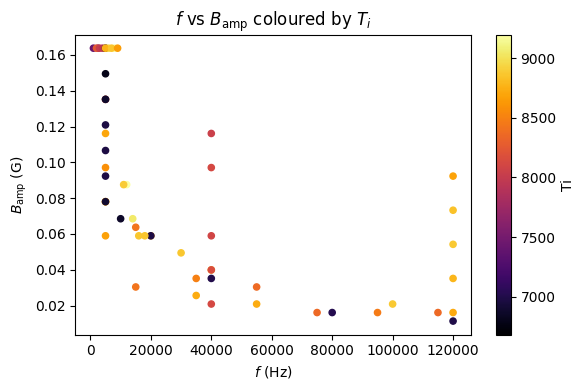

In [136]:
import matplotlib.pyplot as plt

# Drop the hot data
plot_df = results_df[~results_df['filename'].isin(two_time_data_hot)]

# Create the scatter plot
scatter = plot_df.plot.scatter(
    x='freq', 
    y='Bamp', 
    c='Ti', 
    cmap='inferno', 
    colorbar=True,   # Shows the color scale bar on the right
    figsize=(6, 4),
    sharex=False,     # Fixes a common matplotlib bug with x-axis labels
)

# Label the chart
scatter.set_title(r'$f$ vs $B_\mathrm{amp}$ coloured by $T_i$')
scatter.set_xlabel(r'$f$ (Hz)')
scatter.set_ylabel(r'$B_\mathrm{amp}$ (G)')

plt.tight_layout()  # Adjust subplots to fit into figure area.

plt.show()


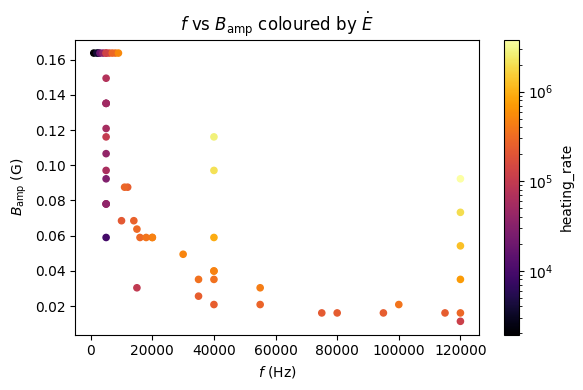

In [137]:
import matplotlib.pyplot as plt


log_norm = mcolors.LogNorm(vmin=plot_df['heating_rate'].min(), vmax=plot_df['heating_rate'].max())

# Create the scatter plot
scatter = plot_df.plot.scatter(
    x='freq', 
    y='Bamp', 
    c='heating_rate', 
    cmap='inferno', 
    colorbar=True,   # Shows the color scale bar on the right
    figsize=(6, 4),
    sharex=False,     # Fixes a common matplotlib bug with x-axis labels
    norm=log_norm
)

# Label the chart
scatter.set_title(r'$f$ vs $B_\mathrm{amp}$ coloured by $\dot{E}$')
scatter.set_xlabel(r'$f$ (Hz)')
scatter.set_ylabel(r'$B_\mathrm{amp}$ (G)')

plt.tight_layout()  # Adjust subplots to fit into figure area.

plt.show()


### Check linear time scaling

In [138]:
df = results_df.copy()

# Get datasets with more than 2 unique time points and sort by frequency
df_filtered = df[df['filename'].isin(linear_time_data)].sort_values(by='freq', 
                    ascending=True, ignore_index=True)

# df_filtered[['filename', 'freq', 'Bamp', 'heating_rate', 'Ti', 'Tf', 'EFi', 'num_time_pts', 'ToTFi']]

In [139]:
drop_index = [2, 4, 7]
df_plot = df_filtered.drop(index=drop_index)

print("Average T/TF is {:.3f} ± {:.3f}".format(df_plot.ToTFi.mean(), df_plot.ToTFi.std()))
print("Average EF is {:.3f} ± {:.3f} kHz".format(df_plot.EFi.mean()/1e3, df_plot.EFi.std()/1e3))

Average T/TF is 0.557 ± 0.013
Average EF is 15.413 ± 0.533 kHz


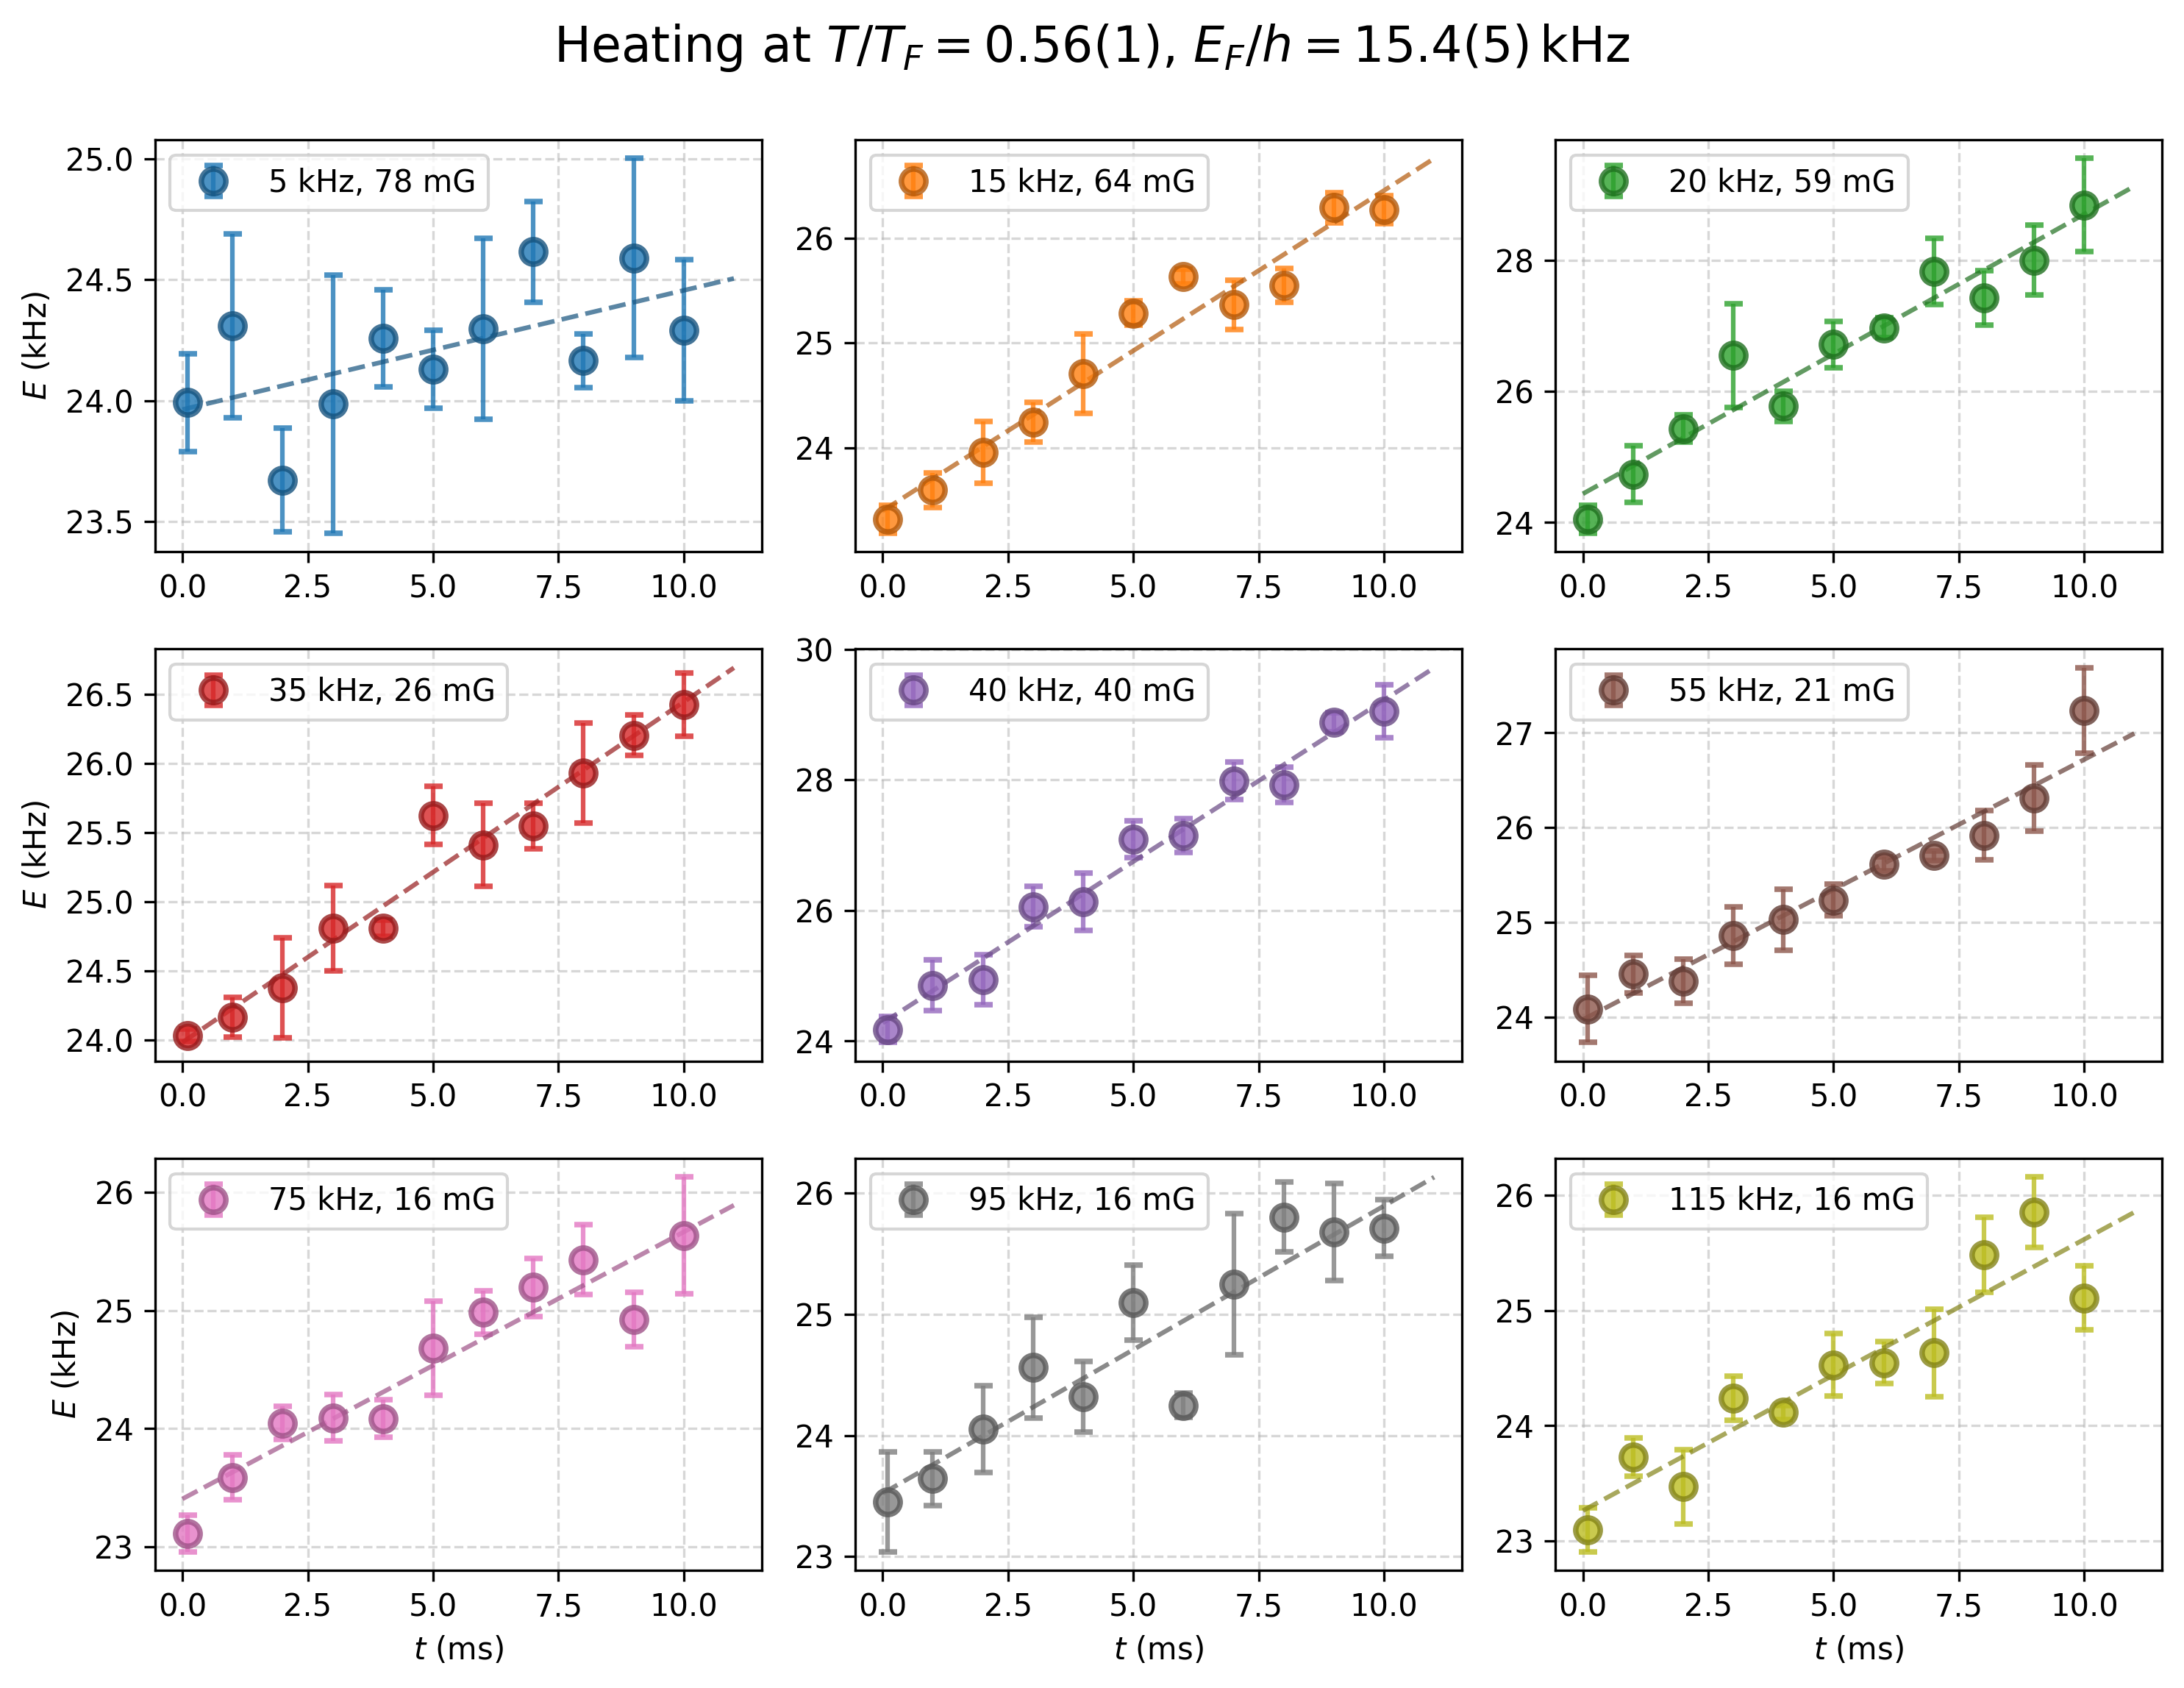

In [113]:
# Plot each frequency group individually to assign distinct colors
fig, axes = plt.subplots(3, 3, figsize=(10, 8), dpi=300)
axs = axes.flatten()  
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = 2*colors

fig.suptitle(r'Heating at $T/T_F = 0.56(1)$, $E_F/h=15.4(5)\,$kHz', fontsize=16, y=0.95)

for i, row in enumerate(df_plot.itertuples(index=False)):
    # print(row)
    ax = axs[i]

    trapped_gas_params = (row.ToTFi, row.EFi, row.barnu)

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it

    data = row.raw_data.groupby('time', as_index=False).agg(
                                    E_mean=('E', 'mean'),
                                    E_sem=('E', 'sem')
                                )
    
    ax.errorbar(
        x=data['time']*1e3,  # ms
        y=data['E_mean']/1e3,    # kHz
        yerr=data['E_sem']/1e3,
        fmt='o',                # 'none' completely hides the internal errorbar marker
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,             # Controls marker size
        label=f'{row.freq/1e3:.0f} kHz, {row.Bamp*1e3:.0f} mG'    # Add a label for the legend
    )

    ts = np.linspace(0, row.total_time, 100)
    ax.plot(ts*1e3, row.heating_rate*ts/1e3 + row.Ei_fit/1e3, 
            color=dark_edge_color, linestyle='--', alpha=0.7)

    if i in [6, 7, 8]:  # Only label the bottom row
        ax.set_xlabel(r'$t$ (ms)')
    if i in [0, 3, 6]:  # Only label the leftmost column
        ax.set_ylabel(r'$E$ (kHz)')
    
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()


fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Compare N>2 datasets to theory

In [140]:
drop_index = [4] # Drop 4, which looks weird. But keep 2 and 7.
df_plot = df_filtered.drop(index=drop_index)

print("Average T/TF is {:.3f} ± {:.3f}".format(df_plot.ToTFi.mean(), df_plot.ToTFi.std()))
print("Average EF is {:.3f} ± {:.3f} kHz".format(df_plot.EFi.mean()/1e3, df_plot.EFi.std()/1e3))

# df_plot['A']

Average T/TF is 0.553 ± 0.016
Average EF is 15.477 ± 0.517 kHz


c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)
C:\Users\coldatoms\AppData\Local\Temp\ipykernel_14144\932600397.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')


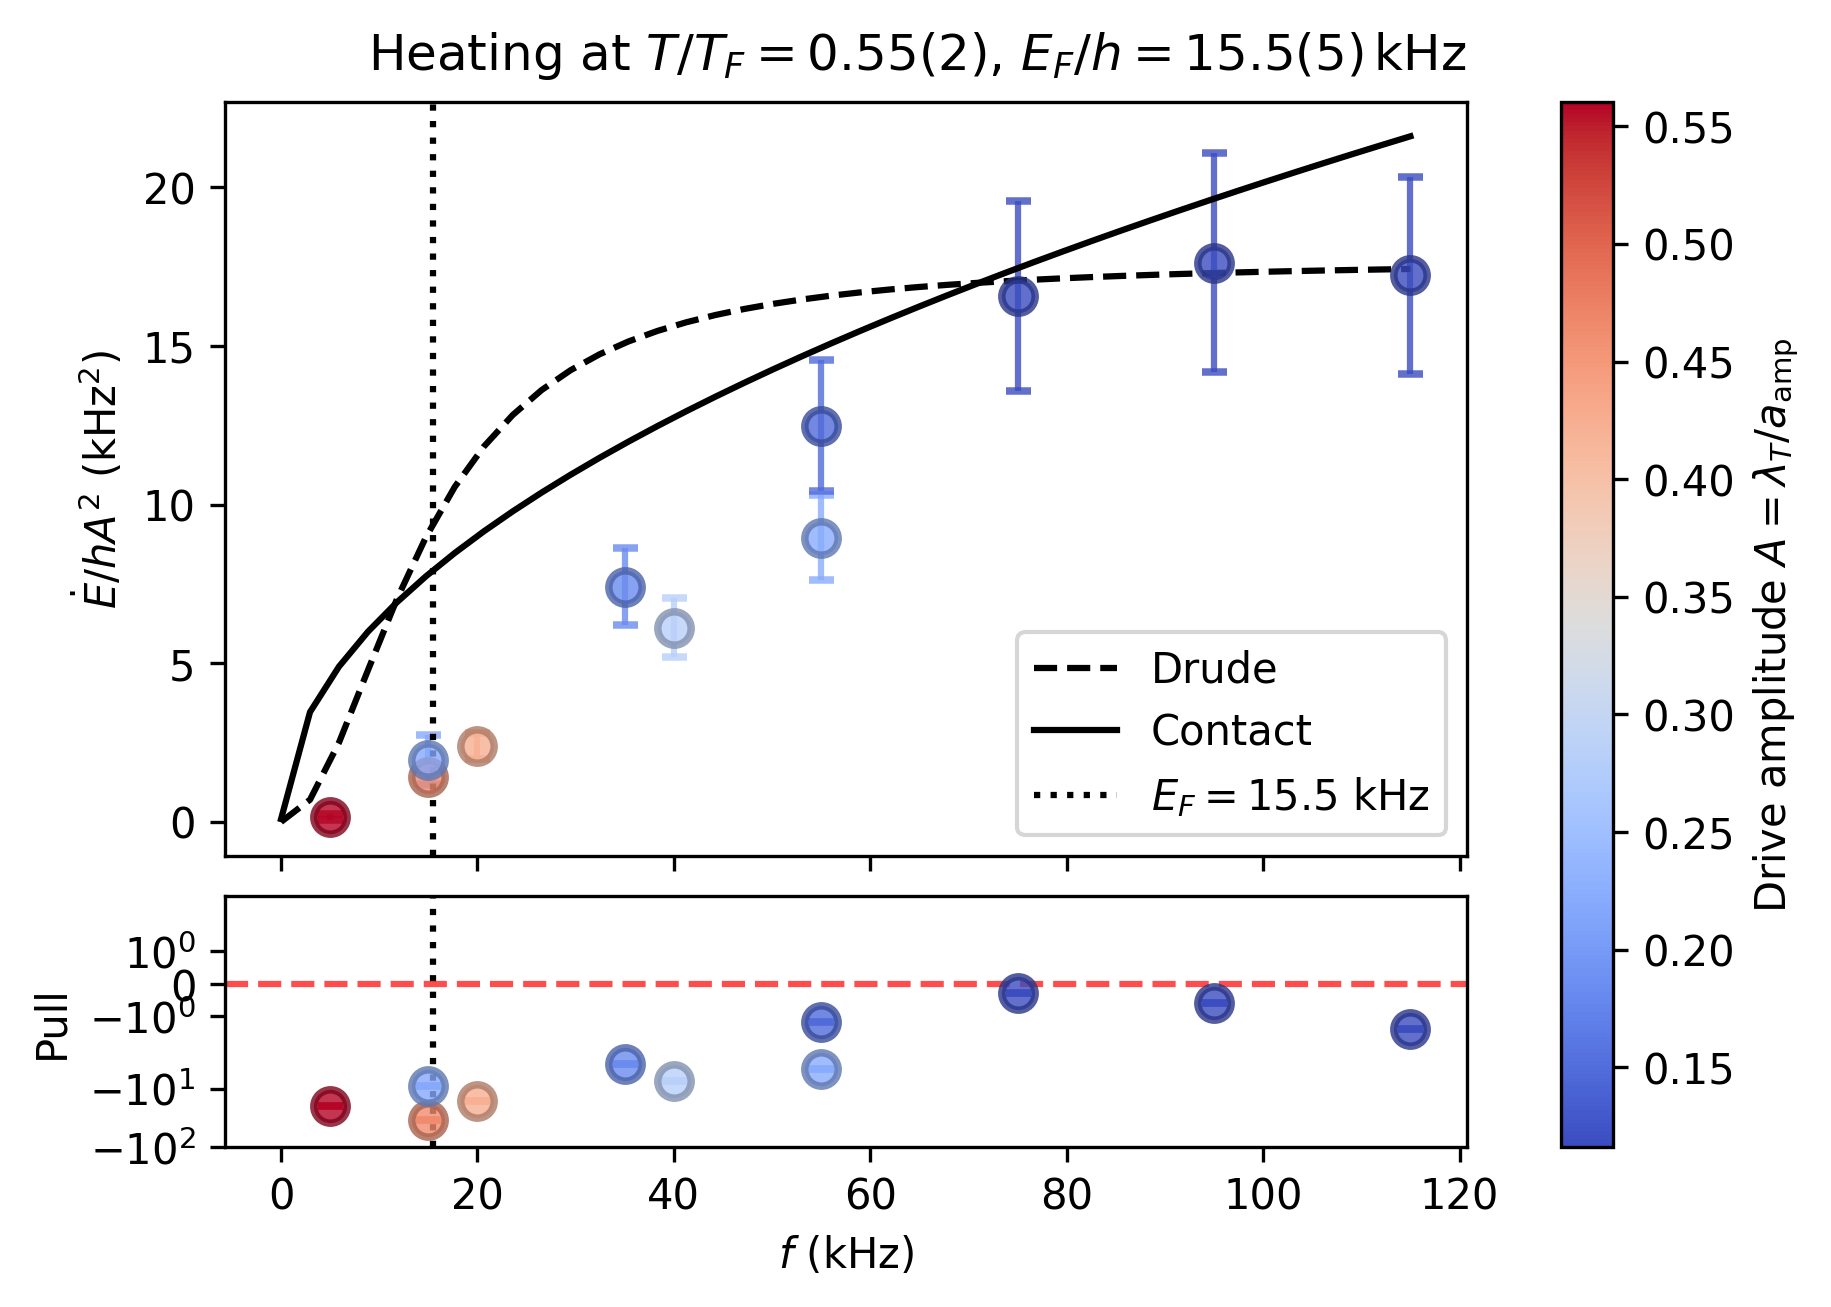

In [115]:
fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(6, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

trapped_gas_params = (df_plot.ToTFi.mean(), df_plot.EFi.mean(), df_plot.barnu.mean())
TUG = TrappedUnitaryGas(*trapped_gas_params)
TUG.modulate_field(np.linspace(2, df_plot.freq.max(), 40))


df_plot['x'] = df_plot.freq/1e3  # kHz
df_plot['y'] = df_plot['norm_heating_rate']/1e6  # kHz^2
df_plot['yerr'] = df_plot['e_norm_heating_rate']/1e6  # kHz^2
df_plot['Edot_th'] = np.interp(df_plot.freq, TUG.nus, TUG.Edot/TUG.Ns/2)
df_plot['y_th'] = df_plot['Edot_th']/1e6  # kHz^2
df_plot['res'] = df_plot['y'] - df_plot['y_th']
df_plot['dev'] = df_plot['res'] / df_plot['y_th'] * 100  # Percent deviation
df_plot['e_dev'] = df_plot['yerr'] / df_plot['y_th'] * 100  # Percent deviation error
df_plot['pull'] = (df_plot['y'] - df_plot['y_th'])/df_plot['yerr']  # Pull value


# Define drive amplitide color mapping
cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=df_plot['A'].min(), vmax=df_plot['A'].max())

for row in df_plot.itertuples():
    # Convert this row's parameter value into a specific RGBA color
    point_color = cmap(norm(row.A))

    rgb = mcolors.to_rgb(point_color)
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        row.x, row.y, yerr=row.yerr, 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )
    
    ax_res.errorbar(
        row.x, row.pull, yerr=np.zeros_like(row.pull), 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )

ax_res.set_xlabel(r'$f$ (kHz)')
ax_res.set_ylabel('Pull')
ax_res.set(yscale='symlog', ylim=(-100, 5))
ax_main.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')

ax_main.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Ns/2/1e6, 'k--', label='Drude')
ax_main.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Ns/2/1e6, 'k-', label='Contact')
ax_main.axvline(x=TUG.EF/1e3, color='k', linestyle=':', 
                label=r'$E_F = $'+f'{TUG.EF/1e3:.1f} kHz')
ax_res.axvline(x=TUG.EF/1e3, color='k', linestyle=':')

ax_main.legend()

ax_res.axhline(y=0, color='r', linestyle='--', alpha=0.7)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=[ax_main, ax_res], orientation='vertical')
cbar.set_label(r'Drive amplitude $A = \lambda_T/a_\mathrm{amp}$')

# fig.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

fig.suptitle(r'Heating at $T/T_F = 0.55(2)$, $E_F/h=15.5(5)\,$kHz', fontsize=12, y=1.05)

plt.show()

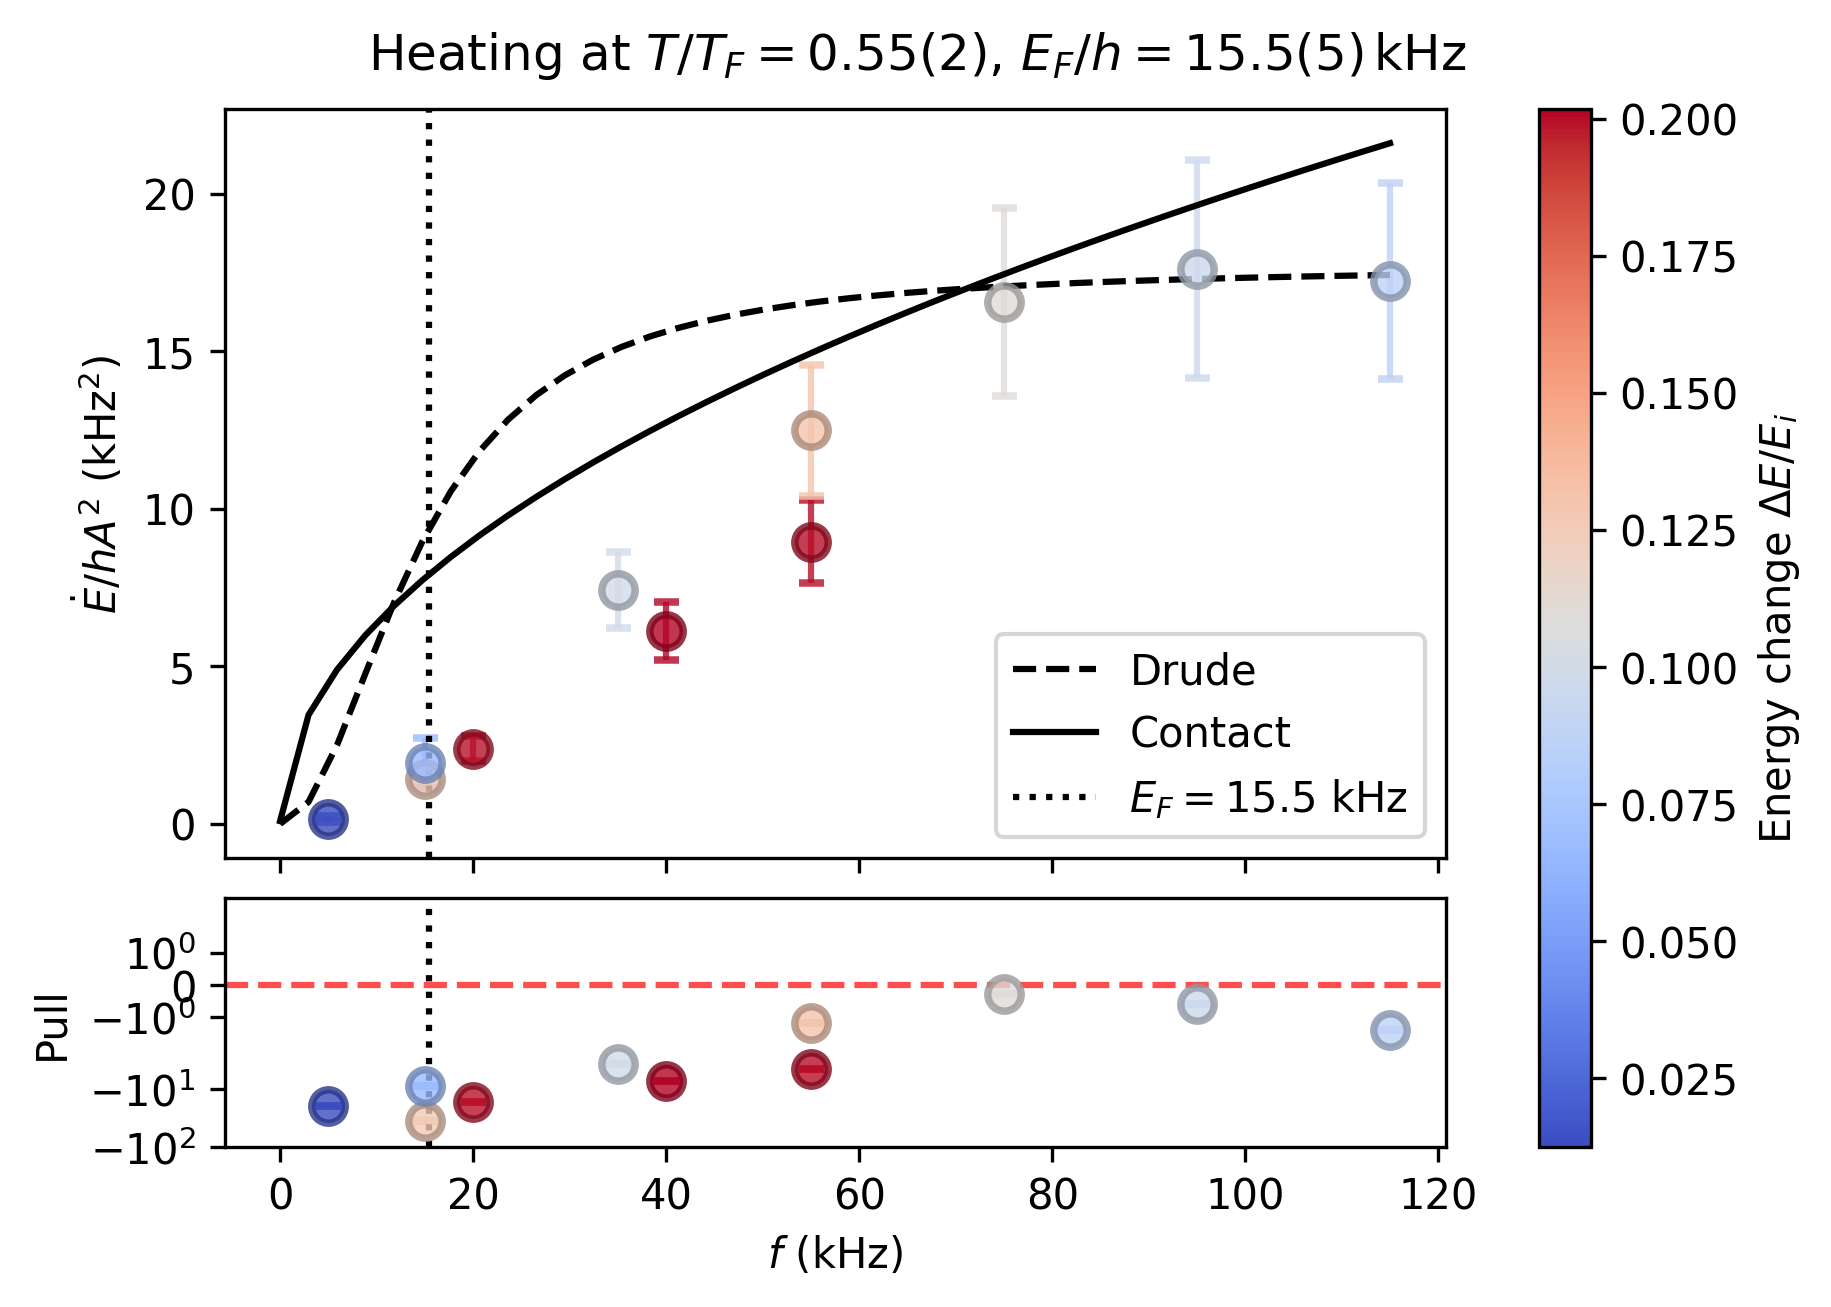

In [ ]:
fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(6, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

# Define change in temperature color mapping
norm = mcolors.Normalize(vmin=df_plot['delta_E_over_E'].min(), 
                         vmax=df_plot['delta_E_over_E'].max())

for row in df_plot.itertuples():
    # Convert this row's parameter value into a specific RGBA color
    point_color = cmap(norm(row.delta_E_over_E))

    rgb = mcolors.to_rgb(point_color)
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        row.x, row.y, yerr=row.yerr, 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )
    
    ax_res.errorbar(
        row.x, row.pull, yerr=np.zeros_like(row.pull), 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )

ax_res.set_xlabel(r'$f$ (kHz)')
ax_res.set_ylabel('Pull')
ax_res.set(yscale='symlog', ylim=(-100, 5))
ax_main.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')

ax_main.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Ns/2/1e6, 'k--', label='Drude')
ax_main.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Ns/2/1e6, 'k-', label='Contact')
ax_main.axvline(x=TUG.EF/1e3, color='k', linestyle=':', 
                label=r'$E_F = $'+f'{TUG.EF/1e3:.1f} kHz')
ax_res.axvline(x=TUG.EF/1e3, color='k', linestyle=':')

ax_main.legend()

ax_res.axhline(y=0, color='r', linestyle='--', alpha=0.7)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=[ax_main, ax_res], orientation='vertical')
cbar.set_label(r'Energy change $\Delta E/E_i$')

# fig.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

fig.suptitle(r'Heating at $T/T_F = 0.55(2)$, $E_F/h=15.5(5)\,$kHz', fontsize=12, y=1.05)

plt.show()

### Compare N = 2 datasets to theory

In [141]:
df = results_df.copy()
df_filtered = df[df['filename'].isin(two_time_data)].sort_values(by='filename', 
                    ascending=True, ignore_index=True)

# Show up to 100 rows
pd.set_option('display.max_rows', 100)

# df_filtered[['filename', 'freq', 'Bamp', 'heating_rate', 'Ei', 'Ef', 'EFi', 'num_time_pts', 'ToTFi']]

In [142]:
drop_index = []
df_plot = df_filtered.drop(index=drop_index)

print("Average T/TF is {:.3f} ± {:.3f}".format(df_plot.ToTFi.mean(), df_plot.ToTFi.std()))
print("Average EF is {:.3f} ± {:.3f} kHz".format(df_plot.EFi.mean()/1e3, df_plot.EFi.std()/1e3))

# df_plot['A']

Average T/TF is 0.562 ± 0.055
Average EF is 14.717 ± 1.838 kHz


c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)
C:\Users\coldatoms\AppData\Local\Temp\ipykernel_14144\3708880512.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')


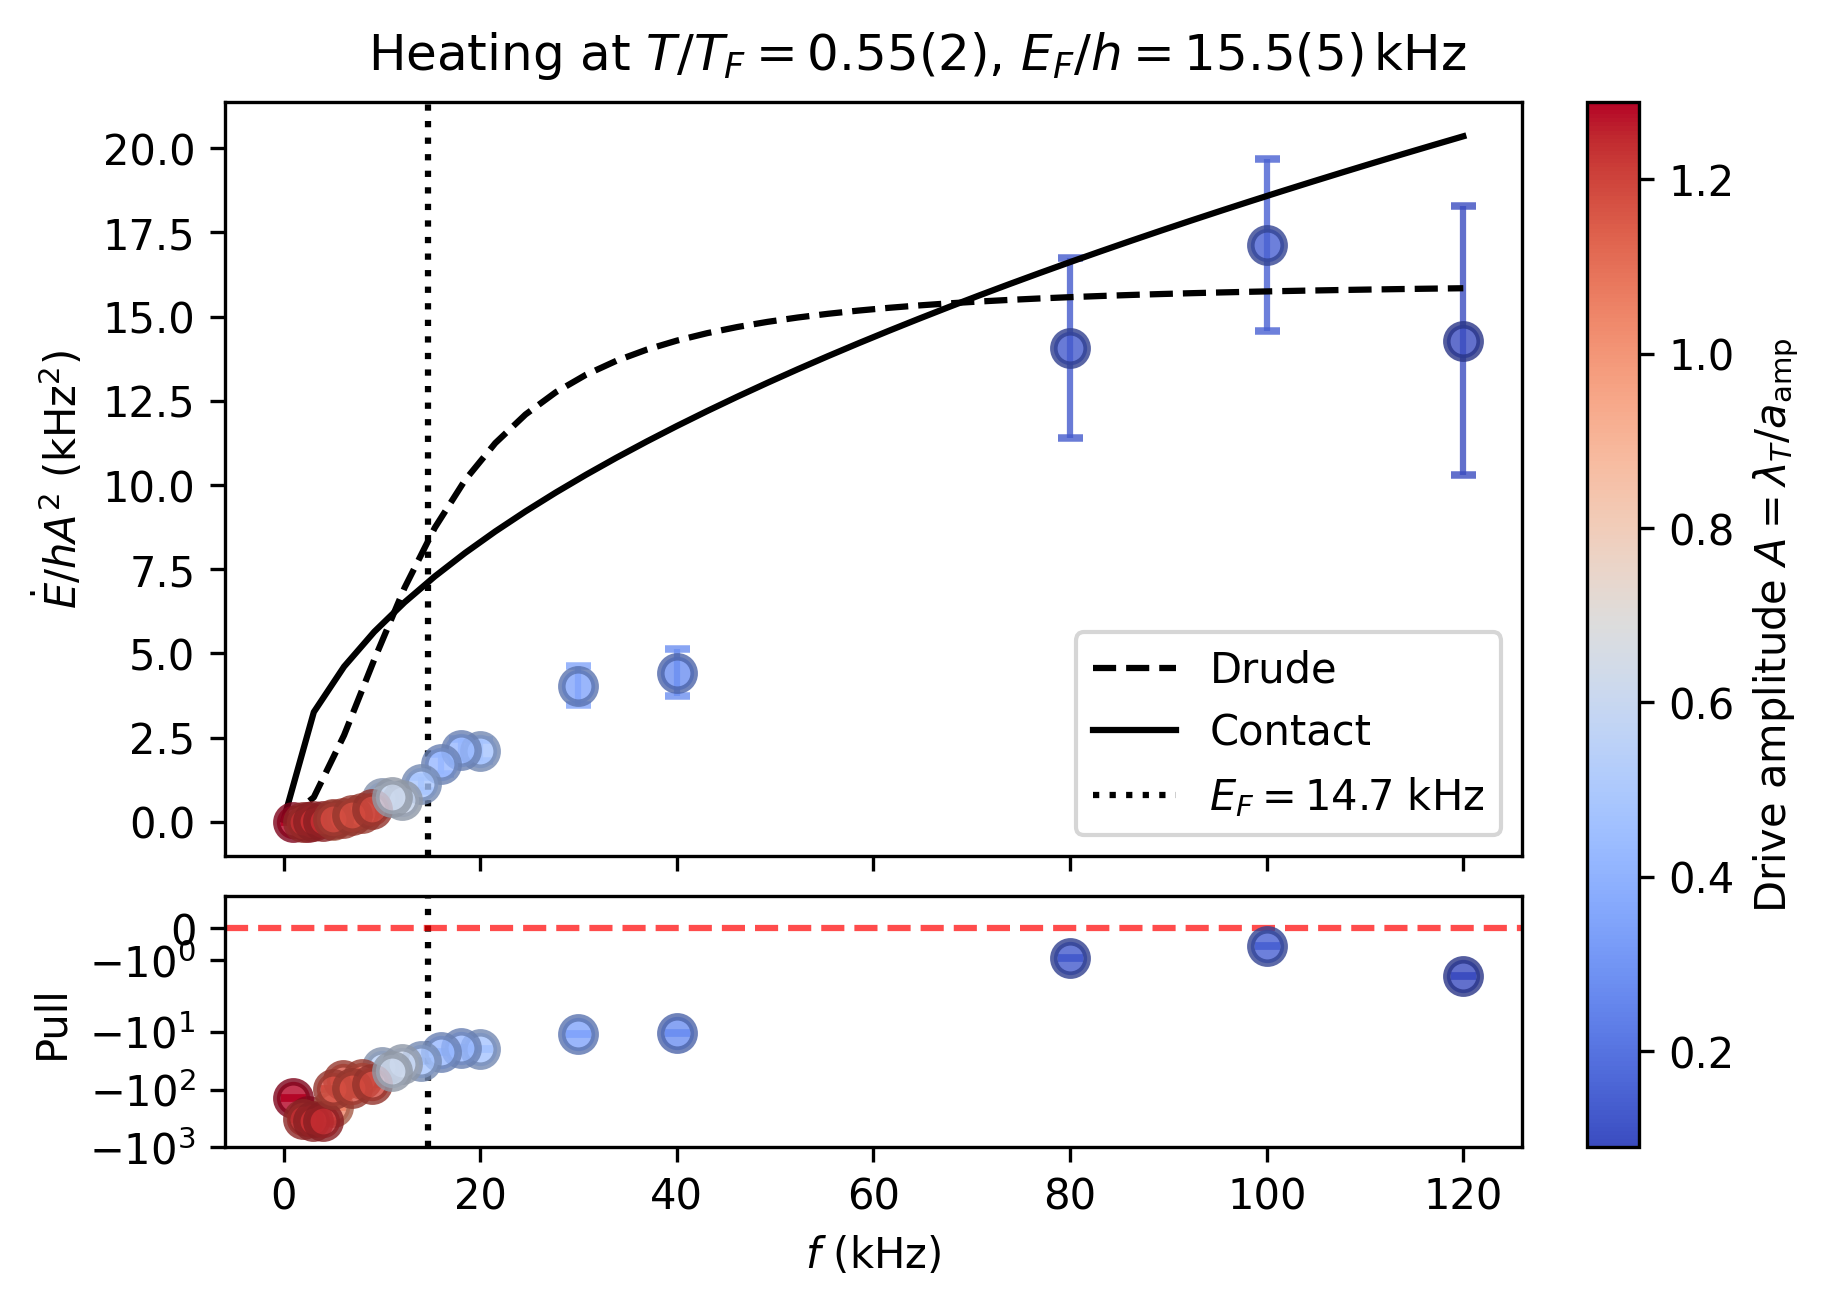

In [ ]:
fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(6, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

fig.suptitle(r'Heating at $T/T_F = 0.55(2)$, $E_F/h=15.5(5)\,$kHz', fontsize=12, y=1.05)

trapped_gas_params = (df_plot.ToTFi.mean(), df_plot.EFi.mean(), df_plot.barnu.mean())
TUG = TrappedUnitaryGas(*trapped_gas_params)
TUG.modulate_field(np.linspace(1, df_plot.freq.max(), 40))


df_plot['x'] = df_plot.freq/1e3  # kHz
df_plot['y'] = df_plot['norm_heating_rate']/1e6  # kHz^2
df_plot['yerr'] = df_plot['e_norm_heating_rate']/1e6  # kHz^2
df_plot['Edot_th'] = np.interp(df_plot.freq, TUG.nus, TUG.Edot/TUG.Ns/2)
df_plot['y_th'] = df_plot['Edot_th']/1e6  # kHz^2
df_plot['res'] = df_plot['y'] - df_plot['y_th']
df_plot['dev'] = df_plot['res'] / df_plot['y_th'] * 100  # Percent deviation
df_plot['e_dev'] = df_plot['yerr'] / df_plot['y_th'] * 100  # Percent deviation error
df_plot['pull'] = (df_plot['y'] - df_plot['y_th'])/df_plot['yerr']  # Pull value


# Define drive amplitide color mapping
cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=df_plot['A'].min(), vmax=df_plot['A'].max())

for row in df_plot.itertuples():
    # Convert this row's parameter value into a specific RGBA color
    point_color = cmap(norm(row.A))

    rgb = mcolors.to_rgb(point_color)
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        row.x, row.y, yerr=row.yerr, 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )
    
    ax_res.errorbar(
        row.x, row.pull, yerr=np.zeros_like(row.pull), 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )

ax_res.set_xlabel(r'$f$ (kHz)')
ax_res.set_ylabel('Pull')
ax_res.set(yscale='symlog', ylim=(-1000, 1))
ax_main.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')

ax_main.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Ns/2/1e6, 'k--', label='Drude')
ax_main.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Ns/2/1e6, 'k-', label='Contact')
ax_main.axvline(x=TUG.EF/1e3, color='k', linestyle=':', 
                label=r'$E_F = $'+f'{TUG.EF/1e3:.1f} kHz')
ax_res.axvline(x=TUG.EF/1e3, color='k', linestyle=':')

ax_main.legend()

ax_res.axhline(y=0, color='r', linestyle='--', alpha=0.7)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=[ax_main, ax_res], orientation='vertical')
cbar.set_label(r'Drive amplitude $A = \lambda_T/a_\mathrm{amp}$')

# fig.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

plt.show()

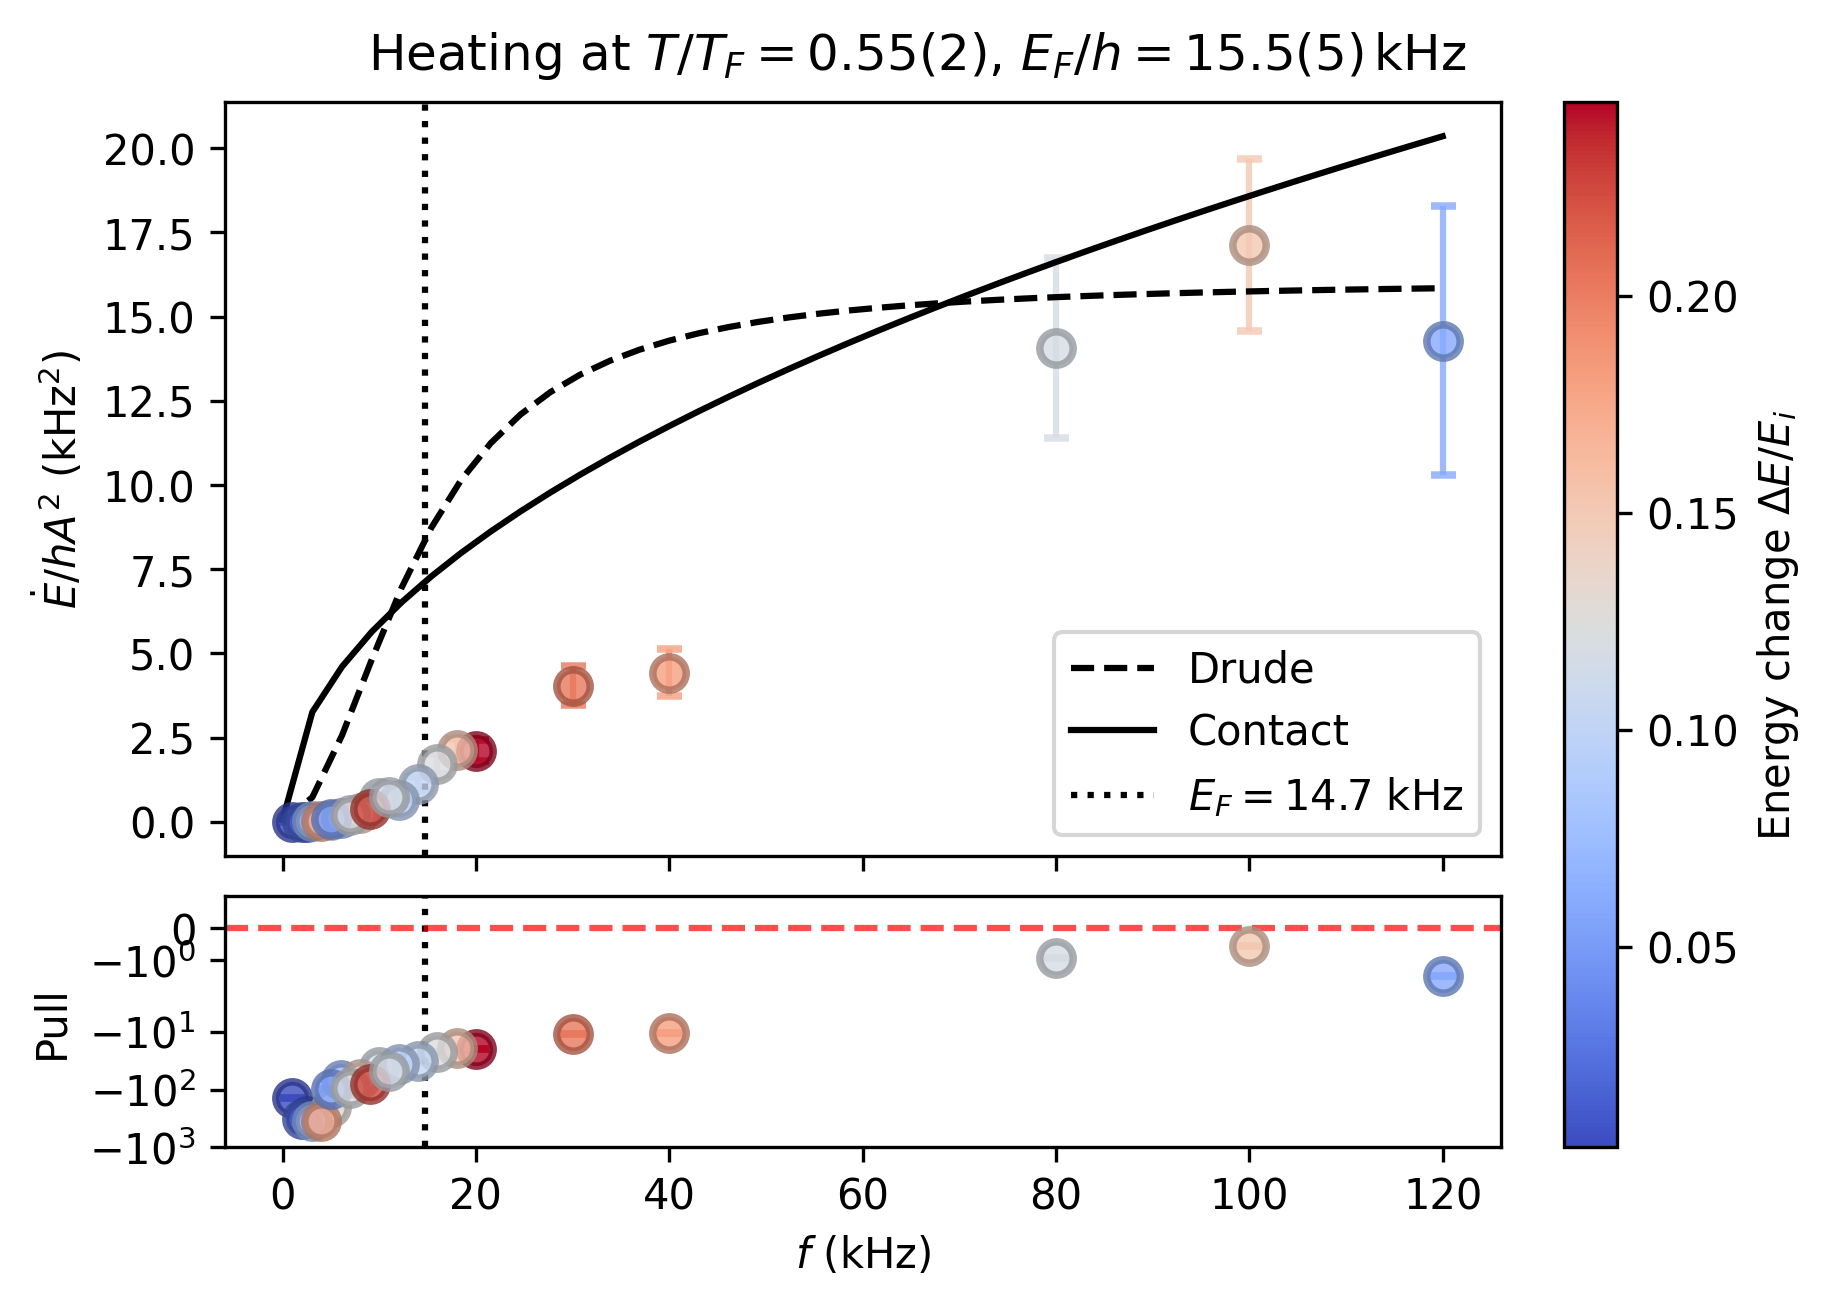

In [120]:
fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(6, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

# Define change in temperature color mapping
# cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=df_plot['delta_E_over_E'].min(), 
                         vmax=df_plot['delta_E_over_E'].max())

for row in df_plot.itertuples():
    # Convert this row's parameter value into a specific RGBA color
    point_color = cmap(norm(row.delta_E_over_E))

    rgb = mcolors.to_rgb(point_color)
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        row.x, row.y, yerr=row.yerr, 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )
    
    ax_res.errorbar(
        row.x, row.pull, yerr=np.zeros_like(row.pull), 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )

ax_res.set_xlabel(r'$f$ (kHz)')
ax_res.set_ylabel('Pull')
ax_res.set(yscale='symlog', ylim=(-1000, 1))
ax_main.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')

ax_main.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Ns/2/1e6, 'k--', label='Drude')
ax_main.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Ns/2/1e6, 'k-', label='Contact')
ax_main.axvline(x=TUG.EF/1e3, color='k', linestyle=':', 
                label=r'$E_F = $'+f'{TUG.EF/1e3:.1f} kHz')
ax_res.axvline(x=TUG.EF/1e3, color='k', linestyle=':')

ax_main.legend()

ax_res.axhline(y=0, color='r', linestyle='--', alpha=0.7)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=[ax_main, ax_res], orientation='vertical')
cbar.set_label(r'Energy change $\Delta E/E_i$')

# fig.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

fig.suptitle(r'Heating at $T/T_F = 0.55(2)$, $E_F/h=15.5(5)\,$kHz', fontsize=12, y=1.05)

plt.show()

### Checking amplitude scaling 

In [121]:
df = results_df.copy()

# Filter the DataFrame to keep only those 3 frequencies
df_filtered = df[df['filename'].isin(amplitude_data)]

drop_index = [17, 18, 19, 20, 21]  # Dropped due to poor SNR
df_plot = df_filtered.drop(index=drop_index)

In [122]:
# df_plot[['filename', 'freq', 'Bamp', 'max_time', 'total_time', 'Ei', 'Ef', 'EFi', 'num_time_pts', 'ToTFi']]

c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:395: RuntimeWarning: invalid value encountered in divide
  self.zetaDrude = self.Edot_drude/self.A**2 * (self.lambda_T**2*self.kF**2)/(9*pi*nus**2*2*self.Ns)
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:396: RuntimeWarning: divide by zero encountered in divide
  self.zetaC = self.Edot_contact/self.A**2 * (self.lambda_T**2*self.kF**2)/(9*pi*nus**2*2*self.Ns)
C:\Users\coldatoms\AppData\Local\Temp\ipykernel_14144\1362630104.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[

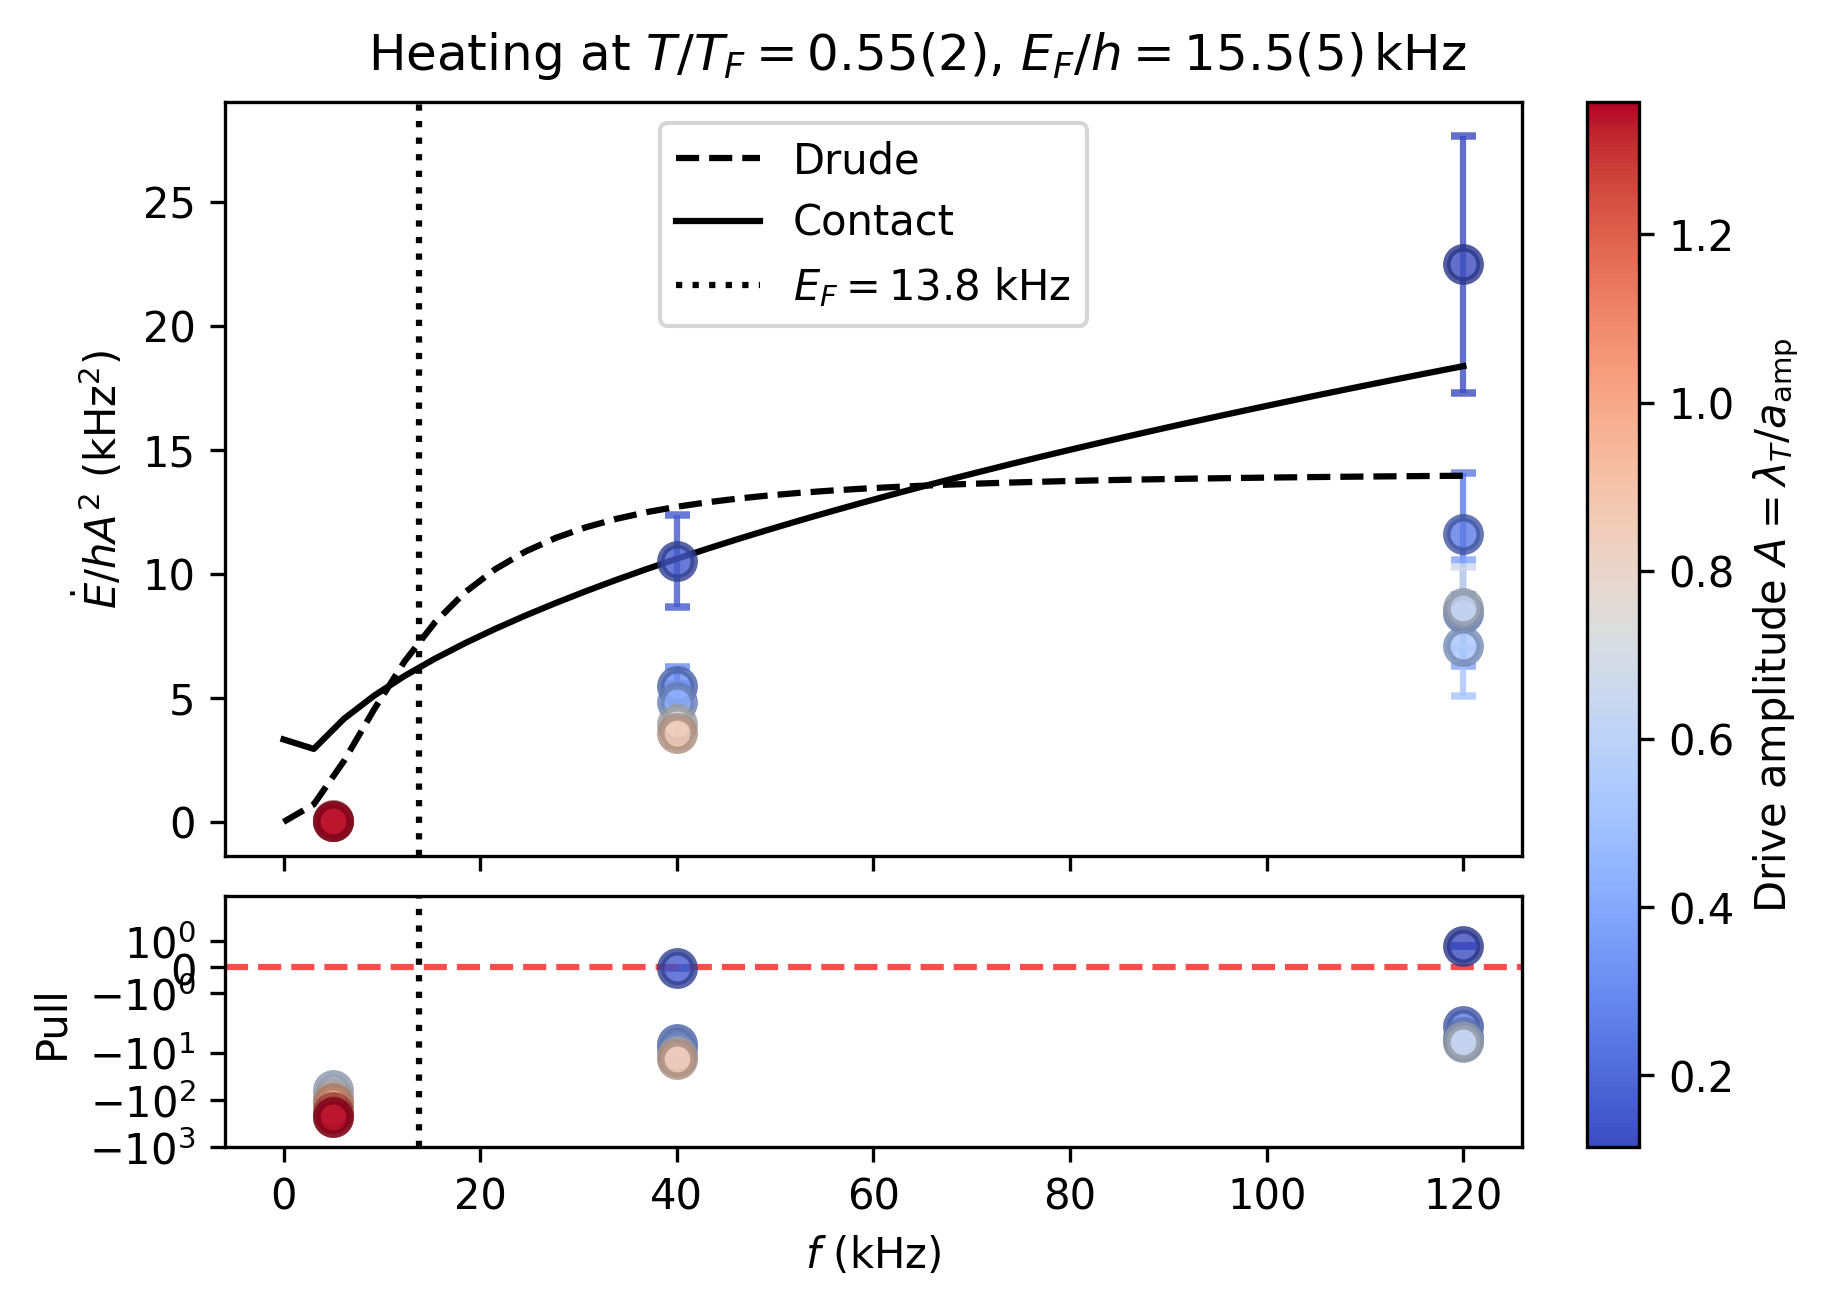

In [123]:
fig, (ax_main, ax_res) = plt.subplots(
    nrows=2, 
    ncols=1, 
    sharex=True, 
    figsize=(6, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

trapped_gas_params = (df_plot.ToTFi.mean(), df_plot.EFi.mean(), df_plot.barnu.mean())
TUG = TrappedUnitaryGas(*trapped_gas_params)
TUG.modulate_field(np.linspace(0, df_plot.freq.max(), 40))


df_plot['x'] = df_plot.freq/1e3  # kHz
df_plot['y'] = df_plot['norm_heating_rate']/1e6  # kHz^2
df_plot['yerr'] = df_plot['e_norm_heating_rate']/1e6  # kHz^2
df_plot['Edot_th'] = np.interp(df_plot.freq, TUG.nus, TUG.Edot/TUG.Ns/2)
df_plot['y_th'] = df_plot['Edot_th']/1e6  # kHz^2
df_plot['res'] = df_plot['y'] - df_plot['y_th']
df_plot['dev'] = df_plot['res'] / df_plot['y_th'] * 100  # Percent deviation
df_plot['e_dev'] = df_plot['yerr'] / df_plot['y_th'] * 100  # Percent deviation error
df_plot['pull'] = (df_plot['y'] - df_plot['y_th'])/df_plot['yerr']  # Pull value


# Define drive amplitide color mapping
cmap = cm.get_cmap('coolwarm')
norm = mcolors.Normalize(vmin=df_plot['A'].min(), vmax=df_plot['A'].max())

for row in df_plot.itertuples():
    # Convert this row's parameter value into a specific RGBA color
    point_color = cmap(norm(row.A))

    rgb = mcolors.to_rgb(point_color)
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        row.x, row.y, yerr=row.yerr, 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )
    
    ax_res.errorbar(
        row.x, row.pull, yerr=np.zeros_like(row.pull), 
        fmt='o',
        color=point_color,
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,
    )

ax_res.set_xlabel(r'$f$ (kHz)')
ax_res.set_ylabel('Pull')
ax_res.set(yscale='symlog', ylim=(-1000, 5))
ax_main.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')

ax_main.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Ns/2/1e6, 'k--', label='Drude')
ax_main.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Ns/2/1e6, 'k-', label='Contact')
ax_main.axvline(x=TUG.EF/1e3, color='k', linestyle=':', 
                label=r'$E_F = $'+f'{TUG.EF/1e3:.1f} kHz')
ax_res.axvline(x=TUG.EF/1e3, color='k', linestyle=':')

ax_main.legend()

ax_res.axhline(y=0, color='r', linestyle='--', alpha=0.7)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=[ax_main, ax_res], orientation='vertical')
cbar.set_label(r'Drive amplitude $A = \lambda_T/a_\mathrm{amp}$')

# fig.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

fig.suptitle(r'Heating at $T/T_F = 0.55(2)$, $E_F/h=15.5(5)\,$kHz', fontsize=12, y=1.05)

plt.show()

Quadratic fits for each frequency:
-------------------------------------
0.5876015126984127 11749.154444444444 289.1379693019477
Frequency: 5000.0 Hz, Fit slope: -0.0063 ± 0.0082, Intercept: 0.058079 ± 0.011536
0.979240880269526
0.5151314 15746.749376023436 323.2660771177012
Frequency: 40000.0 Hz, Fit slope: -3.3954 ± 1.7280, Intercept: 5.972118 ± 0.932704


c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)


1.16121204853176
0.59938772 14687.664 323.2660771177012
Frequency: 120000.0 Hz, Fit slope: -9.5997 ± 9.7586, Intercept: 11.719146 ± 2.949355
0.9520201379653146


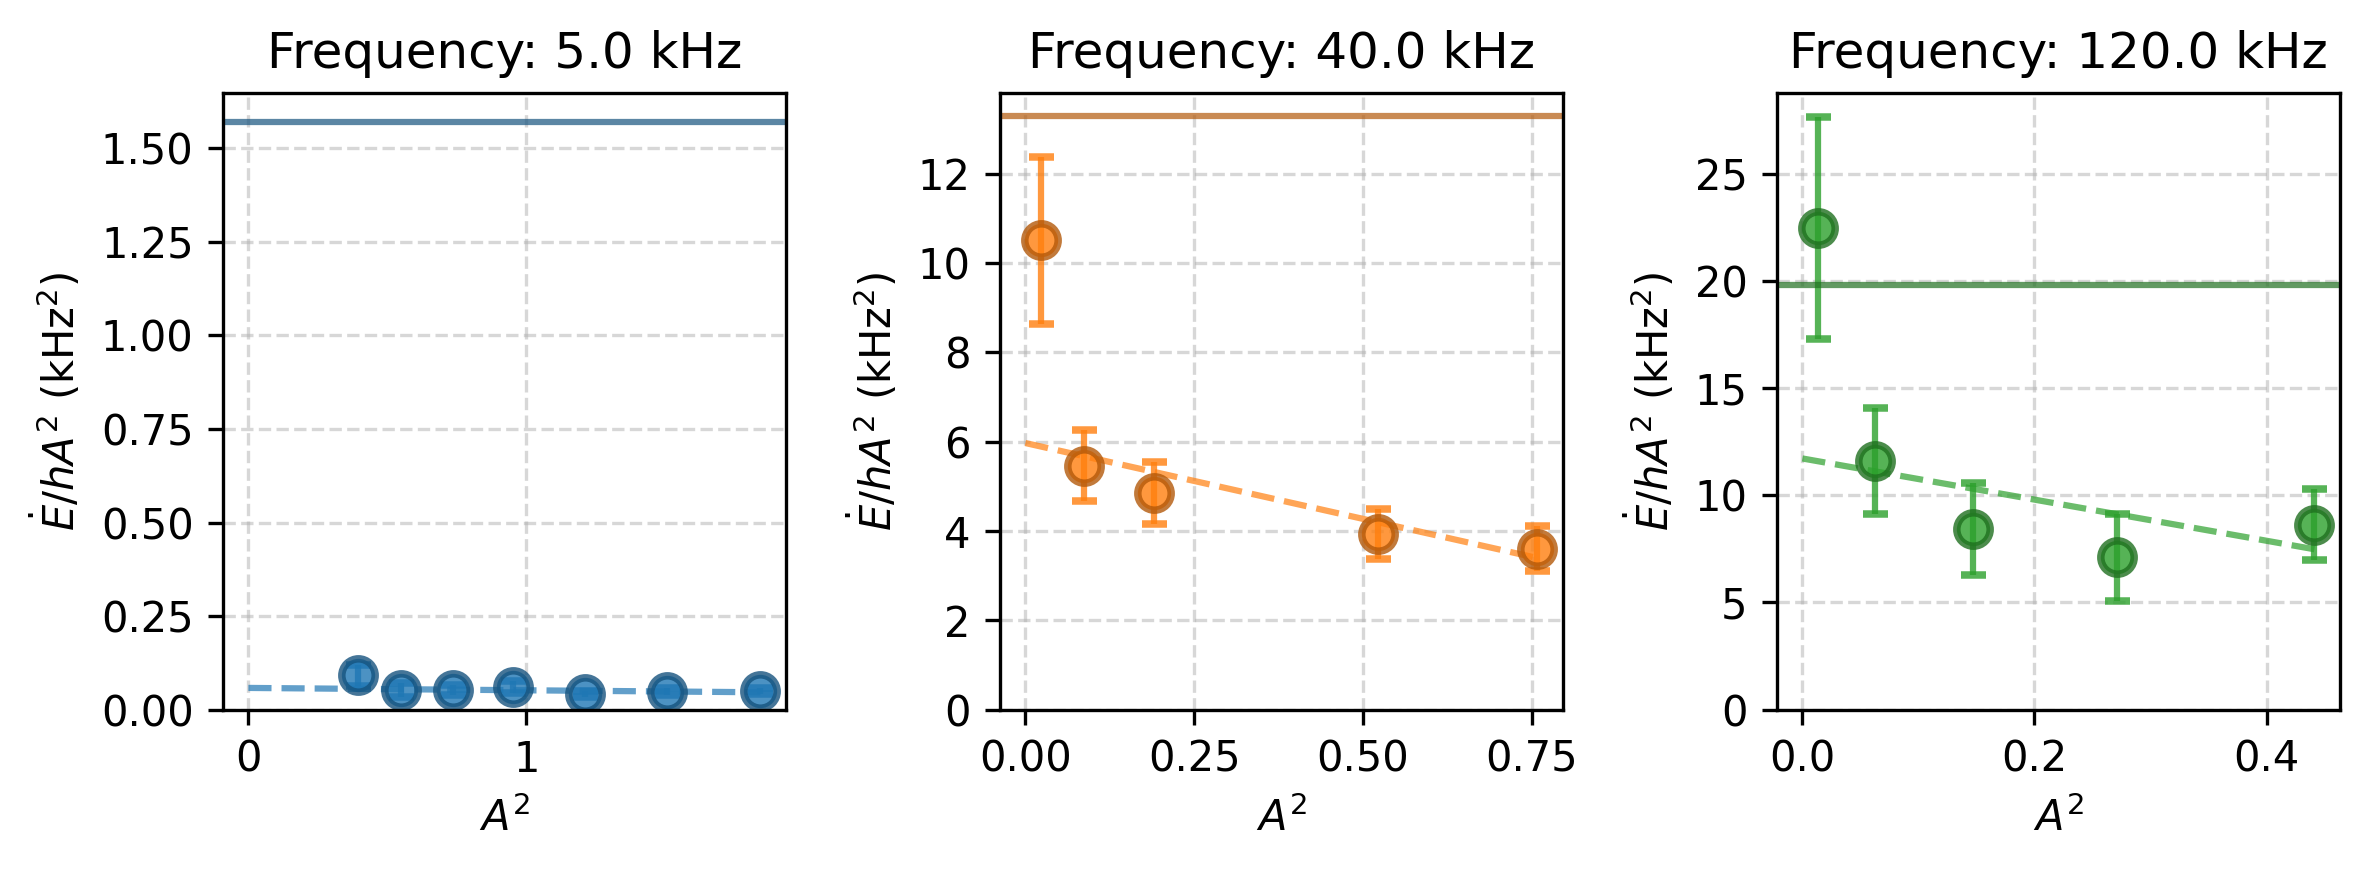

In [124]:
# Set font size back to default
plt.rcParams.update({'font.size': 10})

# Plot each frequency group individually to assign distinct colors
fig, axes = plt.subplots(1, 3, figsize=(8, 3), dpi=300)
axs = axes.flatten()  
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # High-contrast distinct colors

freqs = df_plot['freq'].unique()
freqs.sort()

print("Quadratic fits for each frequency:")
print("-------------------------------------")

for i, freq_val in enumerate(freqs):
    # Filter data for just this specific frequency
    group = df_plot[df_plot['freq'] == freq_val].copy()
    trapped_gas_params = (group['ToTFi'].mean(), group['EFi'].mean(), group['barnu'].mean())

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    axs[i].errorbar(
        x=group['A']**2,
        y=group['norm_heating_rate']/1e6,    # kHz^2
        yerr=group['e_norm_heating_rate']/1e6,
        fmt='o',                # 'none' completely hides the internal errorbar marker
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,                      # Controls marker size
        label=f'{freq_val} Hz'     # Add a label for the legend
    )

    popt, pcov = curve_fit(lambda x, m, b: m * x + b,
                            group['A']**2, 
                            group['norm_heating_rate']/1e6,  # kHz^2
                            sigma=group['e_norm_heating_rate']/1e6
                           )
    perr = np.sqrt(np.diag(pcov))

    print(*trapped_gas_params)
    print(f"Frequency: {freq_val} Hz, Fit slope: {popt[0]:.4f} ± {perr[0]:.4f}, Intercept: {popt[1]:.6f} ± {perr[1]:.6f}")

    TUG = TrappedUnitaryGas(*trapped_gas_params)
    print(TUG.Ctrap)

    a_sqs = np.linspace(0, group['A'].max()**2, 100)
    inv_as = inv_a_amp_from_Bamp(group['B'].mean(), np.sqrt(a_sqs))

    axs[i].plot(a_sqs, np.polyval(popt, a_sqs), color=colors[i], linestyle='--', alpha=0.7)
    axs[i].axhline(y=TUG.calc_Edot(nu=freq_val)/1e6/TUG.Ns/2, color=dark_edge_color, linestyle='-', alpha=0.7)


# Label the chart
for ax in axs:
    ax.set_title(f'Frequency: {freqs[axs.tolist().index(ax)]/1e3} kHz')
    ax.set_ylabel(r'$\dot{E}/hA^2$ (kHz$^2$)')
    ax.set_xlabel(r'$A^2$')
    ax.grid(True, linestyle='--', alpha=0.5)
    # ax.legend(title='Frequencies', loc='lower right')
    _, top = ax.get_ylim()
    ax.set_ylim(bottom=0, top=top)

fig.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()

Reduced chi-squared for saturation fit: 1.1772
ToTF: 0.588, EF: 11.75 kHz, barnu: 289.138
f: 5000.0 Hz, Edot_sat: 0.9554 ± 4.7436, A^2_sat: 18.603672 ± 96.354260
Linearized heating rate: 0.0514 ± 0.0113 kHz^2
Linear fit y-intercept: 0.0077 ± 0.0078 kHz^2
Reduced chi-squared for linear fit: 0.9916


----------------------------------------------
Reduced chi-squared for saturation fit: 6.3854
ToTF: 0.515, EF: 15.75 kHz, barnu: 323.266
f: 40000.0 Hz, Edot_sat: 4.1274 ± 0.8895, A^2_sat: 0.719907 ± 0.214616
Linearized heating rate: 5.7332 ± 0.5628 kHz^2
Linear fit y-intercept: 0.1849 ± 0.0297 kHz^2
Reduced chi-squared for linear fit: 2.3476


----------------------------------------------
Reduced chi-squared for saturation fit: 3.1108
ToTF: 0.599, EF: 14.69 kHz, barnu: 323.266
f: 120000.0 Hz, Edot_sat: 4.6619 ± 3.0398, A^2_sat: 0.361109 ± 0.308850
Linearized heating rate: 12.9100 ± 3.3806 kHz^2
Linear fit y-intercept: 0.1988 ± 0.0322 kHz^2
Reduced chi-squared for linear fit: 0.3335


------

C:\Users\coldatoms\AppData\Local\Temp\ipykernel_14144\4004026826.py:121: UserWarning: The figure layout has changed to tight
  fig.tight_layout()  # Adjust subplots to fit into figure area.


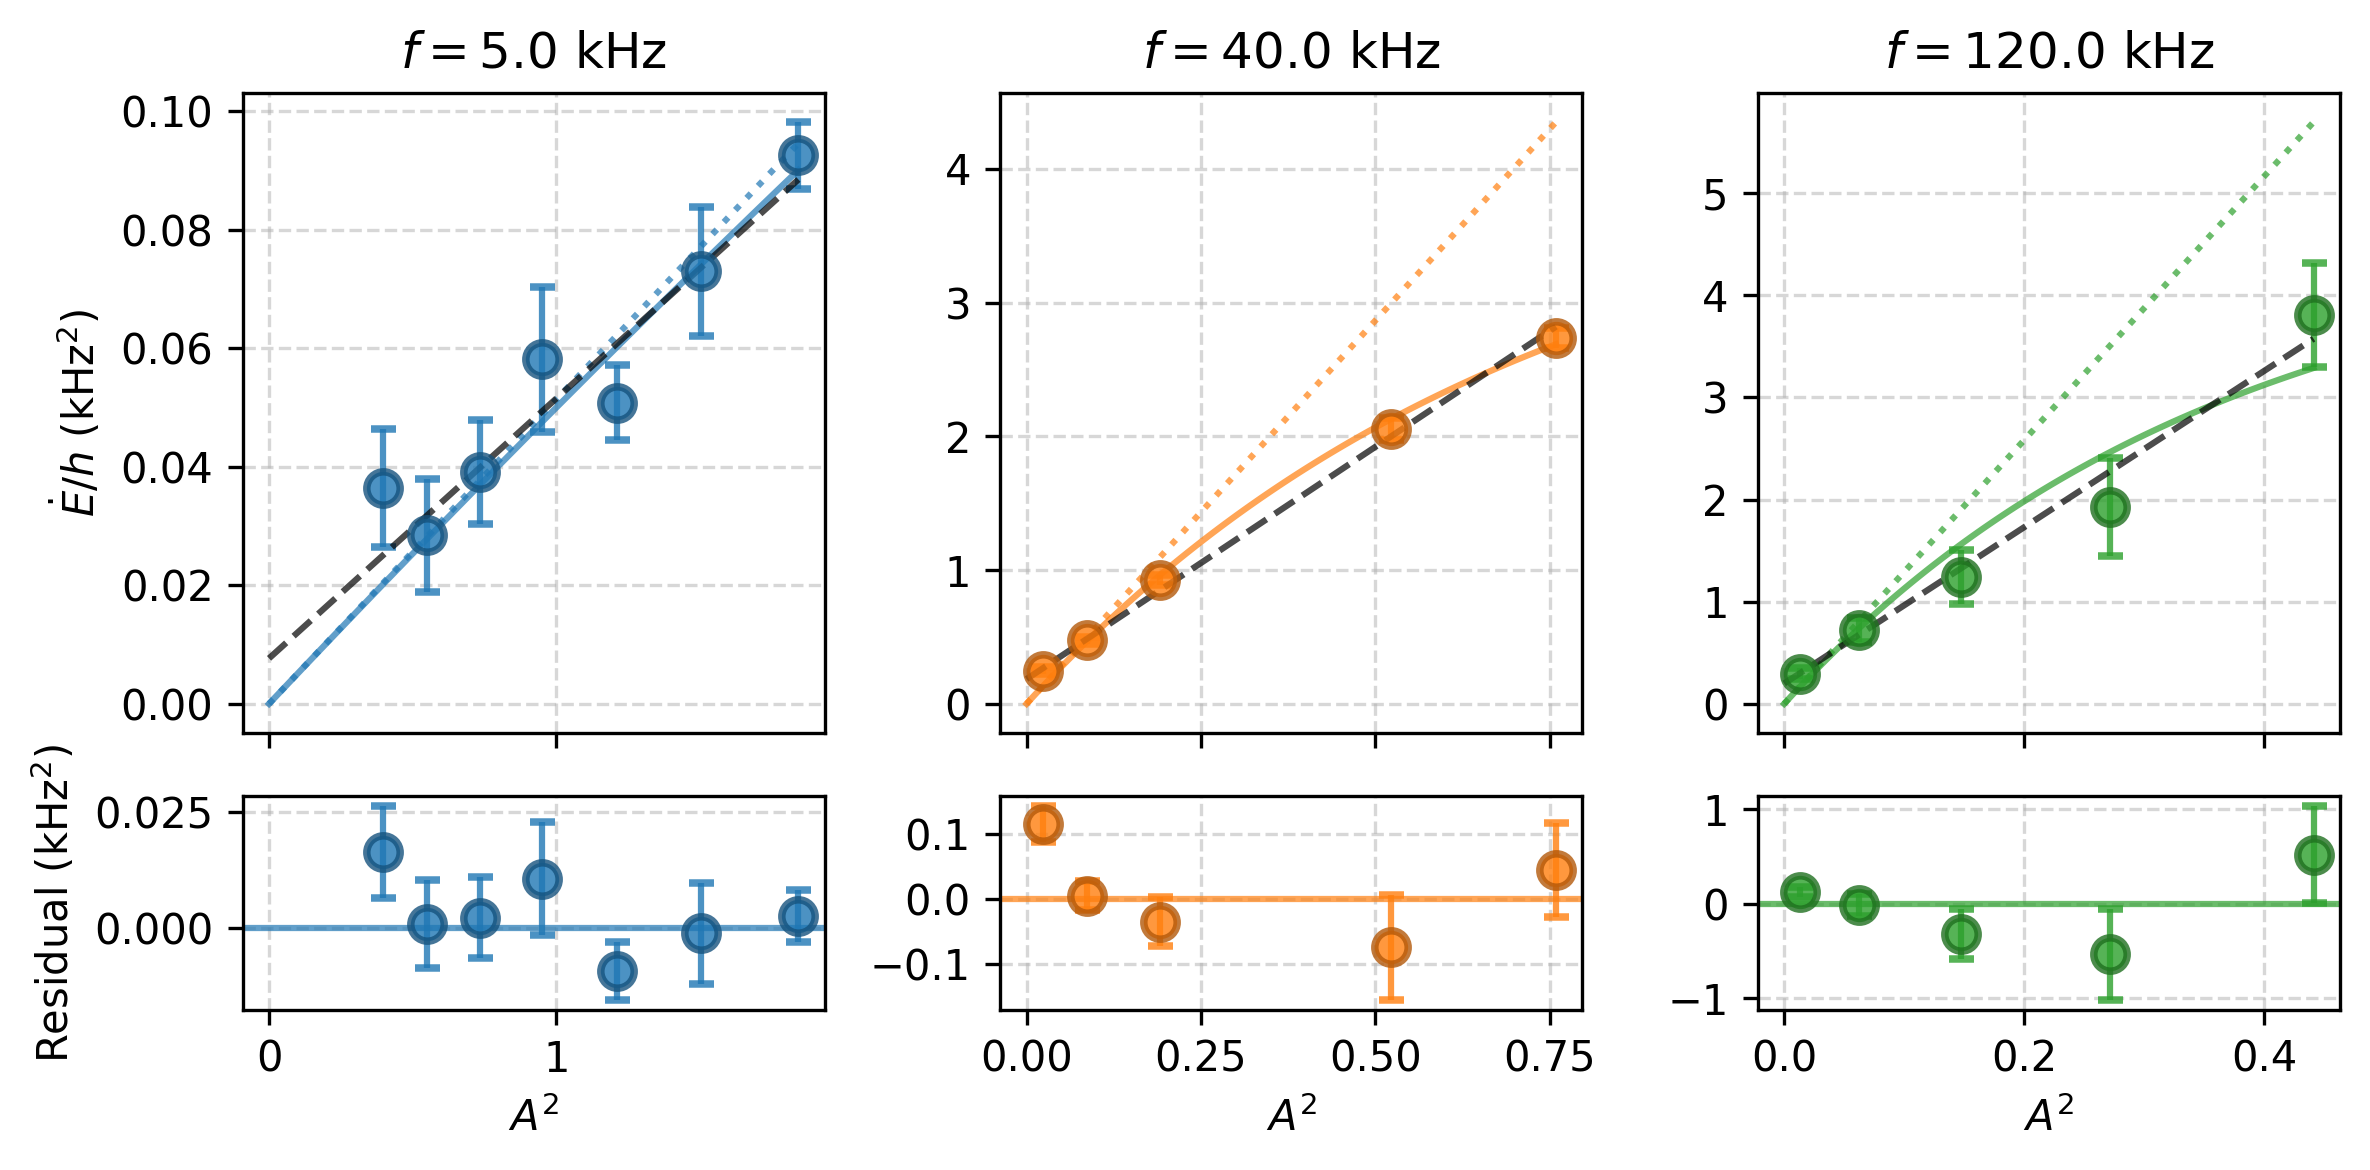

In [129]:
fig, axes = plt.subplots(
    nrows=2, 
    ncols=3, 
    sharex='col', 
    figsize=(8, 4), 
    gridspec_kw={'height_ratios': [3, 1]},
    dpi=300,
    layout='constrained'
)

axs_main = axes[0]  # Top row for main plots
axs_res = axes[1]   # Bottom row for residuals

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # High-contrast distinct colors

df_plot['x'] = df_plot['A']**2 
df_plot['y'] = df_plot['heating_rate']/1e6  # kHz^2
df_plot['yerr'] = df_plot['e_heating_rate']/1e6  # kHz^2

for i, freq_val in enumerate(freqs):
    ax_main = axs_main[i]
    ax_res = axs_res[i]

    # Filter data for just this specific frequency
    group = df_plot[df_plot['freq'] == freq_val].copy()
    trapped_gas_params = (group['ToTFi'].mean(), group['EFi'].mean(), group['barnu'].mean())

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    ax_main.errorbar(
        x=group['x'],
        y=group['y'],    # kHz^2
        yerr=group['yerr'],
        fmt='o',               
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,               
        label=f'{freq_val} Hz' 
    )

    popt, pcov = curve_fit(saturation,
                            group['x'], 
                            group['y'],  # kHz^2
                            sigma=group['yerr'],
                            p0=[group['y'].max(), 4*group['x'].max()]
                           )
    perr = np.sqrt(np.diag(pcov))
    linear_heating_rate = popt[0]/popt[1]
    e_linear_heating_rate = quotient_propagation(linear_heating_rate, popt[0], popt[1], perr[0], 
							  perr[1], pcov[0,1])

    group['res'] = group['y'] - saturation(group['x'], *popt)
    chi_sq = np.sum((group['res']/group['yerr'])**2)
    dof = len(group['x']) - len(popt)
    red_chi_sq = chi_sq / dof
    print(f"Reduced chi-squared for saturation fit: {red_chi_sq:.4f}")

    # print(*trapped_gas_params)
    print(f"ToTF: {trapped_gas_params[0]:.3f}, EF: {trapped_gas_params[1]/1e3:.2f} kHz, barnu: {trapped_gas_params[2]:.3f}")
    print(f"f: {freq_val} Hz, Edot_sat: {popt[0]:.4f} ± {perr[0]:.4f}, A^2_sat: {popt[1]:.6f} ± {perr[1]:.6f}")
    print(f"Linearized heating rate: {linear_heating_rate:.4f} ± {e_linear_heating_rate:.4f} kHz^2")

    xs = np.linspace(0, group['x'].max(), 100)
    ax_main.plot(xs, saturation(xs, *popt), color=colors[i], linestyle='-', alpha=0.7)
    ax_main.plot(xs, popt[0]/popt[1] * xs, color=colors[i], linestyle=':', alpha=0.7)

    ax_res.errorbar(
        x=group['x'],
        y=group['res'],    # kHz^2
        yerr=group['yerr'],
        fmt='o',               
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,            
        label=f'{freq_val} Hz'
    )


    # Linear fit
    popt, pcov = curve_fit(linear,
                            group['x'], 
                            group['y'],  # kHz^2
                            sigma=group['yerr'],
                            p0=[group['y'].max(), group['x'].max()]
                           )
    perr = np.sqrt(np.diag(pcov))

    print(f"Linear fit y-intercept: {popt[1]:.4f} ± {perr[1]:.4f} kHz^2")

    group['res_linear'] = group['y'] - linear(group['x'], *popt)
    chi_sq_linear = np.sum((group['res_linear']/group['yerr'])**2)
    dof_linear = len(group['x']) - len(popt)
    red_chi_sq_linear = chi_sq_linear / dof_linear
    print(f"Reduced chi-squared for linear fit: {red_chi_sq_linear:.4f}")

    xs = np.linspace(0, group['x'].max(), 100)
    ax_main.plot(xs, linear(xs, *popt), color='k', linestyle='--', alpha=0.7)

    ax_res.axhline(y=0, color=colors[i], linestyle='-', alpha=0.7)

    ax_main.set_title(r'$f = $' + f'{freqs[i]/1e3} kHz')

    if i == 0:  # Only label the leftmost column
        ax_main.set_ylabel(r'$\dot{E}/h$ (kHz$^2$)')
        ax_res.set_ylabel(r'Residual (kHz$^2$)')
    ax_res.set_xlabel(r'$A^2$')
    ax_main.grid(True, linestyle='--', alpha=0.5)
    ax_res.grid(True, linestyle='--', alpha=0.5)

    print("\n")
    print("----------------------------------------------")

fig.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()


### Show all data

### Test heating rate theory curves

c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:359: RuntimeWarning: invalid value encountered in scalar divide
  Edot_C = 9*pi*(self.T*betaomega)**2/(betaomega)**(3/2) * pifactors * self.Ctrap \
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:392: RuntimeWarning: invalid value encountered in divide
  self.zetaDrude = self.Edot_drude/self.A**2 * (self.lambda_T**2*self.kF**2)/(9*pi*nus**2*2*self.Ns)


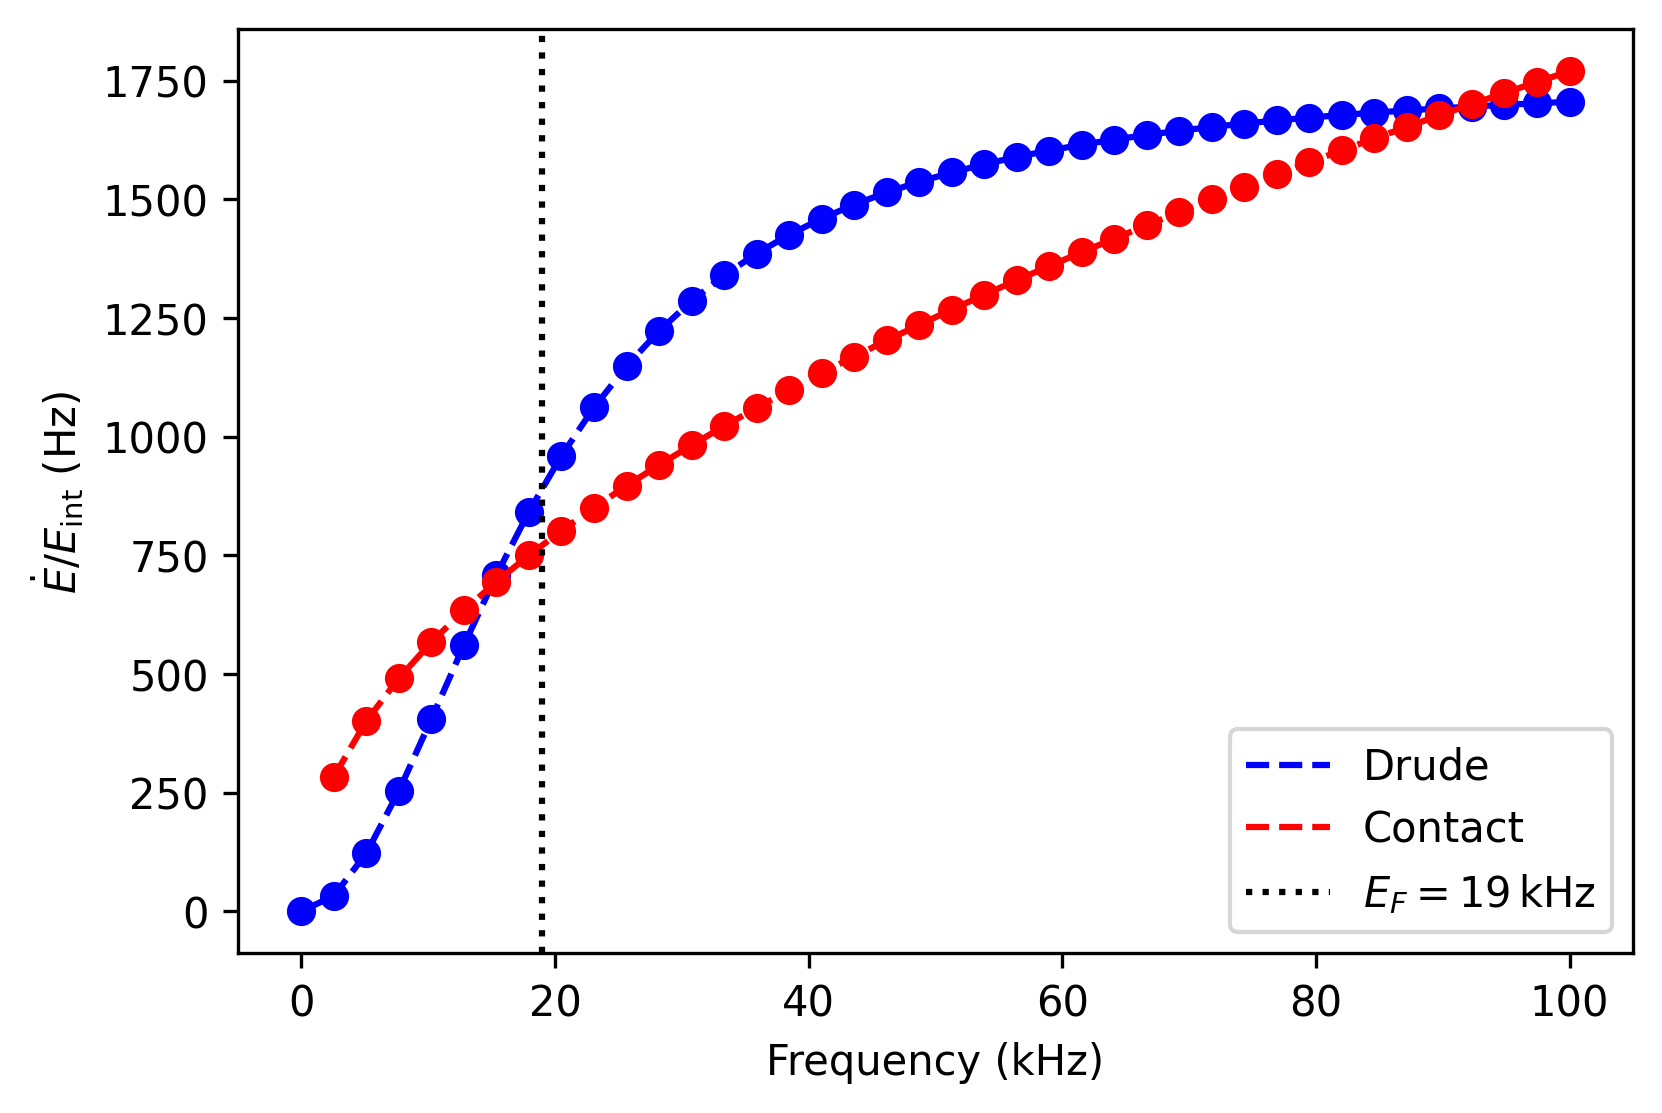

In [47]:
ToTF = 0.58
EF = 19e3
barnu = 305

TUG = TrappedUnitaryGas(ToTF=ToTF, EF=EF, barnu=barnu)

TUG.modulate_field(np.linspace(0, 100e3, 40))

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Epot, 'b--', label='Drude')
plt.plot(TUG.nus/1e3, TUG.Edot_drude/TUG.Epot, 'o', color='b', markersize=6)

plt.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Epot, 'r--', label='Contact')
plt.plot(TUG.nus/1e3, TUG.Edot_contact/TUG.Epot, 'o', color='r', markersize=6)

plt.xlabel('Frequency (kHz)')
plt.ylabel(r'$\dot{E}/E_\mathrm{int}$ (Hz)')

plt.axvline(x=TUG.EF/1e3, color='k', linestyle=':', label=r'$E_F = 19\,$kHz')

plt.legend()

plt.savefig('figures/heating_rate_vs_frequency.pdf', dpi=300, bbox_inches='tight')

plt.show()